In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.utils import shuffle
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, TimeSeriesSplit
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.decomposition import PCA
from scipy import stats
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, mean_absolute_error, mean_absolute_percentage_error

# Dataset

## Data Loading

In [3]:
silica_df = pd.read_csv("MiningProcess_Flotation_Plant_Database.csv",decimal=',')
silica_df['date'] = pd.to_datetime(silica_df['date'])
silica_df.set_index('date', inplace=True)

## Data Exploration

In [4]:
print(silica_df.shape)

(737453, 23)


In [5]:
silica_df

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
date,,,,,,,,,,,,,,,,,,,,,
2017-03-10 01:00:00,55.20,16.98,3019.53,557.434,395.713,10.06640,1.74000,249.214,253.235,250.576,...,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
2017-03-10 01:00:00,55.20,16.98,3024.41,563.965,397.383,10.06720,1.74000,249.719,250.532,250.862,...,248.994,451.891,429.560,432.939,448.086,496.363,445.922,498.075,66.91,1.31
2017-03-10 01:00:00,55.20,16.98,3043.46,568.054,399.668,10.06800,1.74000,249.741,247.874,250.313,...,248.071,451.240,468.927,434.610,449.688,484.411,447.826,458.567,66.91,1.31
2017-03-10 01:00:00,55.20,16.98,3047.36,568.665,397.939,10.06890,1.74000,249.917,254.487,250.049,...,251.147,452.441,458.165,442.865,446.210,471.411,437.690,427.669,66.91,1.31
2017-03-10 01:00:00,55.20,16.98,3033.69,558.167,400.254,10.06970,1.74000,250.203,252.136,249.895,...,248.928,452.441,452.900,450.523,453.670,462.598,443.682,425.679,66.91,1.31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-09-09 23:00:00,49.75,23.20,2710.94,441.052,386.570,9.62129,1.65365,302.344,298.786,299.163,...,313.695,392.160,430.702,872.008,418.725,497.548,446.357,416.892,64.27,1.71
2017-09-09 23:00:00,49.75,23.20,2692.01,473.436,384.939,9.62063,1.65352,303.013,301.879,299.487,...,236.700,401.505,404.616,864.409,418.377,506.398,372.995,426.337,64.27,1.71
2017-09-09 23:00:00,49.75,23.20,2692.20,500.488,383.496,9.61874,1.65338,303.662,307.397,299.487,...,225.879,408.899,399.316,867.598,419.531,503.414,336.035,433.130,64.27,1.71


In [6]:
silica_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 737453 entries, 2017-03-10 01:00:00 to 2017-09-09 23:00:00
Data columns (total 23 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   % Iron Feed                   737453 non-null  float64
 1   % Silica Feed                 737453 non-null  float64
 2   Starch Flow                   737453 non-null  float64
 3   Amina Flow                    737453 non-null  float64
 4   Ore Pulp Flow                 737453 non-null  float64
 5   Ore Pulp pH                   737453 non-null  float64
 6   Ore Pulp Density              737453 non-null  float64
 7   Flotation Column 01 Air Flow  737453 non-null  float64
 8   Flotation Column 02 Air Flow  737453 non-null  float64
 9   Flotation Column 03 Air Flow  737453 non-null  float64
 10  Flotation Column 04 Air Flow  737453 non-null  float64
 11  Flotation Column 05 Air Flow  737453 non-null  float64
 12  Flotation 

In [7]:
silica_df.describe()

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
count,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,...,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000
mean,56.294739,14.651716,2869.140569,488.144697,397.578372,9.767639,1.680380,280.151856,277.159965,281.082397,...,290.754856,520.244823,522.649555,531.352662,420.320973,425.251706,429.941018,421.021231,65.050068,2.326763
std,5.157744,6.807439,1215.203734,91.230534,9.699785,0.387007,0.069249,29.621288,30.149357,28.558268,...,28.670105,131.014924,128.165050,150.842164,91.794432,84.535822,89.862225,84.891491,1.118645,1.125554
min,42.740000,1.310000,0.002026,241.669000,376.249000,8.753340,1.519820,175.510000,175.156000,176.469000,...,185.962000,149.218000,210.752000,126.255000,162.201000,166.991000,155.841000,175.349000,62.050000,0.600000
25%,52.670000,8.940000,2076.320000,431.796000,394.264000,9.527360,1.647310,250.281000,250.457000,250.855000,...,256.302000,416.978000,441.883000,411.325000,356.679000,357.653000,358.497000,356.772000,64.370000,1.440000
50%,56.080000,13.850000,3018.430000,504.393000,399.249000,9.798100,1.697600,299.344000,296.223000,298.696000,...,299.011000,491.878000,495.956000,494.318000,411.974000,408.773000,424.664575,411.065000,65.210000,2.000000
75%,59.720000,19.600000,3727.730000,553.257000,402.968000,10.038000,1.728330,300.149000,300.690000,300.382000,...,301.904000,594.114000,595.464000,601.249000,485.549000,484.329000,492.684000,476.465000,65.860000,3.010000
max,65.780000,33.400000,6300.230000,739.538000,418.641000,10.808100,1.853250,373.871000,375.992000,364.346000,...,371.593000,862.274000,828.919000,886.822000,680.359000,675.644000,698.861000,659.902000,68.010000,5.530000


In [8]:
silica_df.isna().any()

% Iron Feed                     False
% Silica Feed                   False
Starch Flow                     False
Amina Flow                      False
Ore Pulp Flow                   False
Ore Pulp pH                     False
Ore Pulp Density                False
Flotation Column 01 Air Flow    False
Flotation Column 02 Air Flow    False
Flotation Column 03 Air Flow    False
Flotation Column 04 Air Flow    False
Flotation Column 05 Air Flow    False
Flotation Column 06 Air Flow    False
Flotation Column 07 Air Flow    False
Flotation Column 01 Level       False
Flotation Column 02 Level       False
Flotation Column 03 Level       False
Flotation Column 04 Level       False
Flotation Column 05 Level       False
Flotation Column 06 Level       False
Flotation Column 07 Level       False
% Iron Concentrate              False
% Silica Concentrate            False
dtype: bool

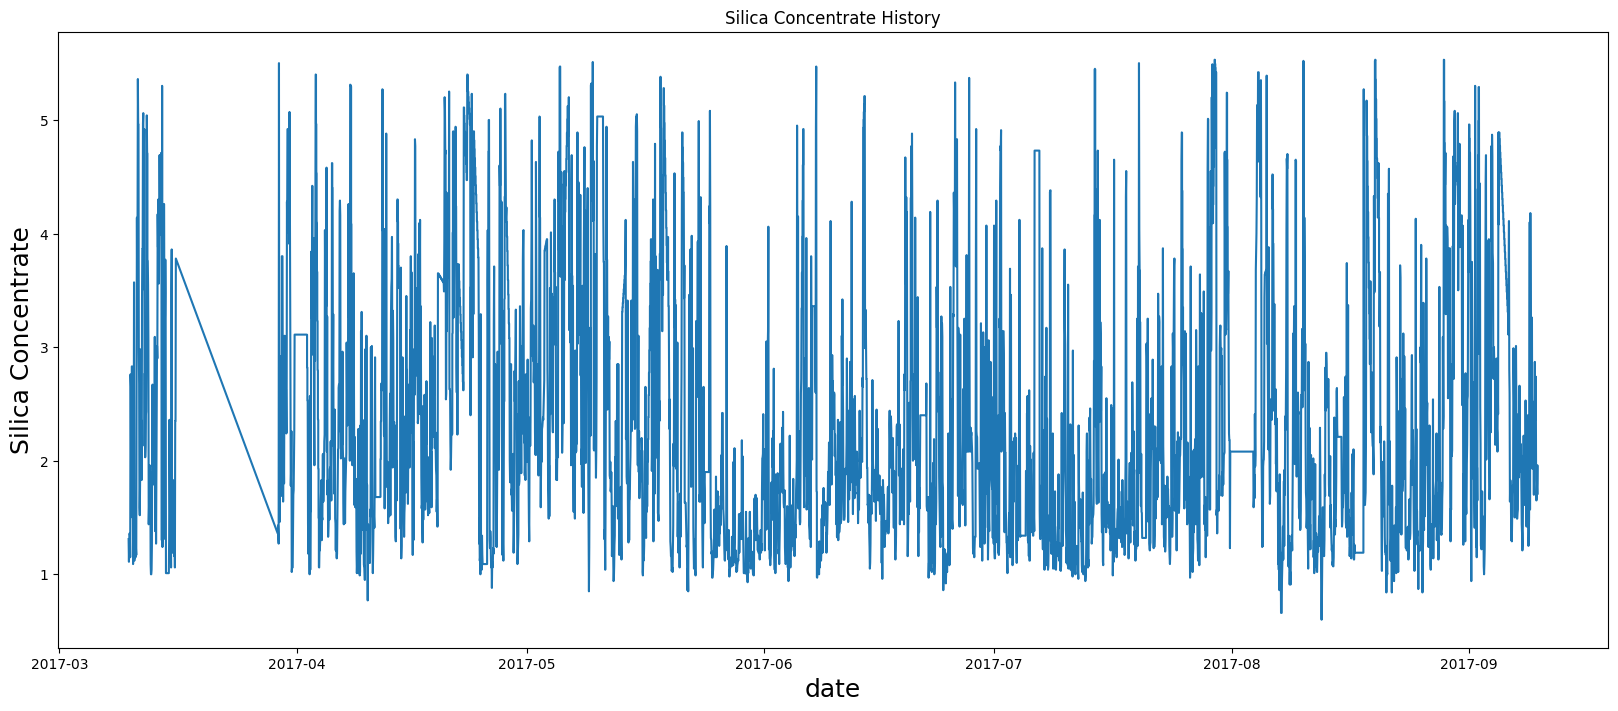

In [9]:
plt.figure(figsize=(20, 8))
plt.title('Silica Concentrate History')
plt.plot(silica_df['% Silica Concentrate'])
plt.xlabel('date', fontsize=18)
plt.ylabel('Silica Concentrate', fontsize=18)
plt.show()

## Change to Hourly Base

In [10]:
start_date = silica_df.index.min()
end_date = silica_df.index.max()
reference_date_range = pd.date_range(start=start_date, end=end_date, freq='H')

# Step 2: Identify missing date points
missing_dates = reference_date_range[~reference_date_range.isin(silica_df.index)]

# Step 3: Print or process the missing dates
if len(missing_dates) > 0:
    print("Missing date points:")
    print(missing_dates)
else:
    print("No missing date points.")

Missing date points:
DatetimeIndex(['2017-03-16 06:00:00', '2017-03-16 07:00:00',
               '2017-03-16 08:00:00', '2017-03-16 09:00:00',
               '2017-03-16 10:00:00', '2017-03-16 11:00:00',
               '2017-03-16 12:00:00', '2017-03-16 13:00:00',
               '2017-03-16 14:00:00', '2017-03-16 15:00:00',
               ...
               '2017-03-29 02:00:00', '2017-03-29 03:00:00',
               '2017-03-29 04:00:00', '2017-03-29 05:00:00',
               '2017-03-29 06:00:00', '2017-03-29 07:00:00',
               '2017-03-29 08:00:00', '2017-03-29 09:00:00',
               '2017-03-29 10:00:00', '2017-03-29 11:00:00'],
              dtype='datetime64[ns]', length=318, freq='H')


### Check Every Hour Data Points

In [11]:
# Initialize a variable to track any hour with a different count of data points
hours_with_different_count = []

# Iterate through each hour
for hour in silica_df.index.hour.unique():
    # Filter the data for the current hour
    data_for_hour = silica_df[silica_df.index.hour == hour]
    # Check if the current hour has 180 data points
    if data_for_hour.shape[0] != 180:
        # Get the date from the index of the first data point in the hour
        date = data_for_hour.index[0].date()
        hours_with_different_count.append((date, hour))

# Check if any hour has a different count of data points
if len(hours_with_different_count) == 0:
    print("Every hour has 180 data points.")
else:
    print("The following hours do not have 180 data points:")
    for date, hour in hours_with_different_count:
        print(f"{date} - {hour}:00")

The following hours do not have 180 data points:
2017-03-10 - 1:00
2017-03-10 - 2:00
2017-03-10 - 3:00
2017-03-10 - 4:00
2017-03-10 - 5:00
2017-03-10 - 6:00
2017-03-10 - 7:00
2017-03-10 - 8:00
2017-03-10 - 9:00
2017-03-10 - 10:00
2017-03-10 - 11:00
2017-03-10 - 12:00
2017-03-10 - 13:00
2017-03-10 - 14:00
2017-03-10 - 15:00
2017-03-10 - 16:00
2017-03-10 - 17:00
2017-03-10 - 18:00
2017-03-10 - 19:00
2017-03-10 - 20:00
2017-03-10 - 21:00
2017-03-10 - 22:00
2017-03-10 - 23:00
2017-03-11 - 0:00


(3948, 23)


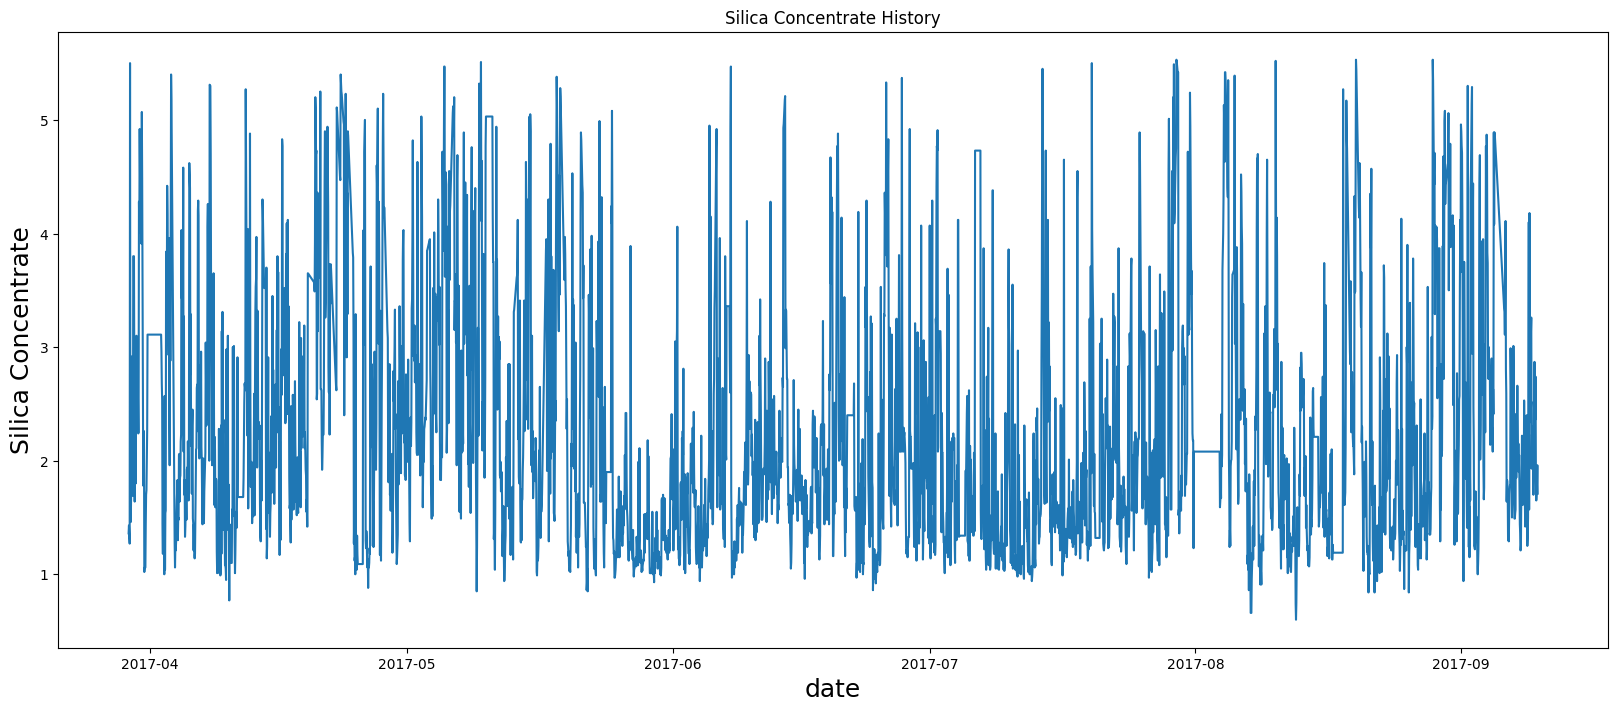

In [12]:
# select 2017-03-29 12:00:00 as start date and time due to the last missing hour is 2017-03-29 11:00:00
# resample the data to hourly base by calculate the mean
start_date = '2017-03-29 12:00:00'
silica_df = silica_df[silica_df.index >= start_date]
silica_df = silica_df.resample('H').mean()
silica_df = silica_df.dropna()

print(silica_df.shape)

plt.figure(figsize=(20, 8))
plt.title('Silica Concentrate History')
plt.plot(silica_df['% Silica Concentrate'])
plt.xlabel('date', fontsize=18)
plt.ylabel('Silica Concentrate', fontsize=18)
plt.show()

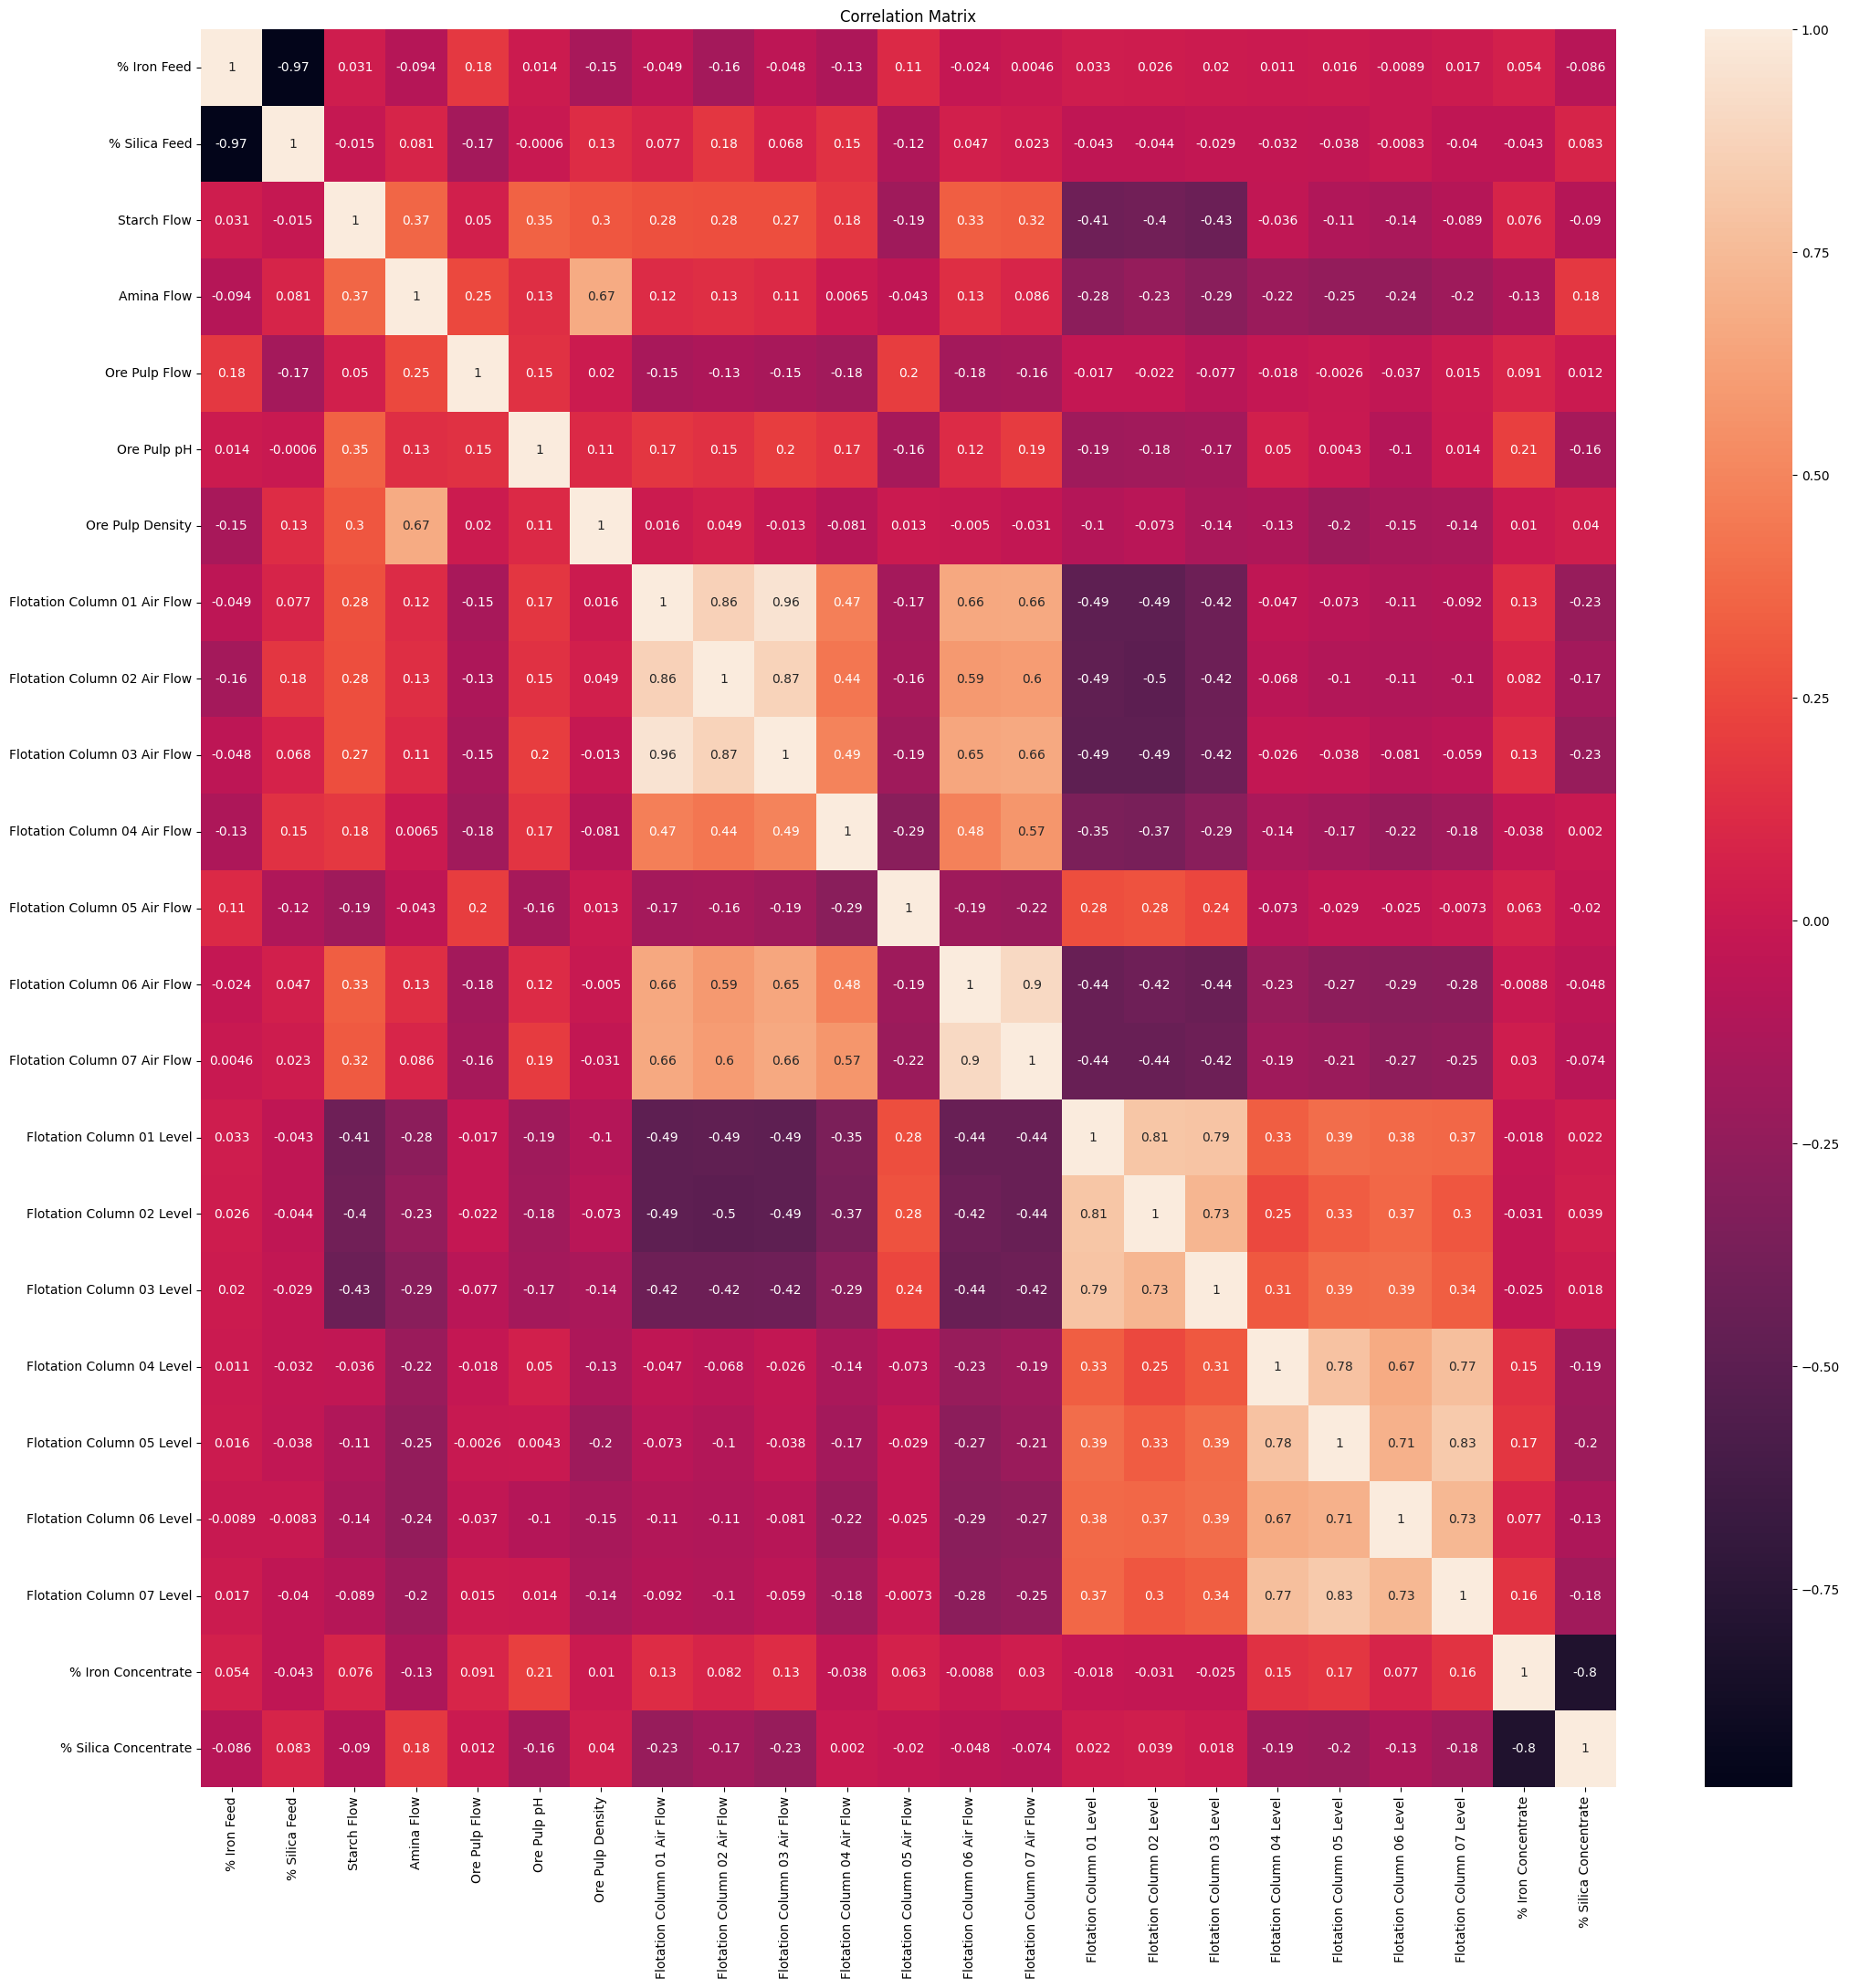

In [13]:
plt.figure(figsize=(25,25))
sns.heatmap(silica_df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

array([[<Axes: title={'center': '% Iron Feed'}>,
        <Axes: title={'center': '% Silica Feed'}>,
        <Axes: title={'center': 'Starch Flow'}>,
        <Axes: title={'center': 'Amina Flow'}>,
        <Axes: title={'center': 'Ore Pulp Flow'}>],
       [<Axes: title={'center': 'Ore Pulp pH'}>,
        <Axes: title={'center': 'Ore Pulp Density'}>,
        <Axes: title={'center': 'Flotation Column 01 Air Flow'}>,
        <Axes: title={'center': 'Flotation Column 02 Air Flow'}>,
        <Axes: title={'center': 'Flotation Column 03 Air Flow'}>],
       [<Axes: title={'center': 'Flotation Column 04 Air Flow'}>,
        <Axes: title={'center': 'Flotation Column 05 Air Flow'}>,
        <Axes: title={'center': 'Flotation Column 06 Air Flow'}>,
        <Axes: title={'center': 'Flotation Column 07 Air Flow'}>,
        <Axes: title={'center': 'Flotation Column 01 Level'}>],
       [<Axes: title={'center': 'Flotation Column 02 Level'}>,
        <Axes: title={'center': 'Flotation Column 03 Level

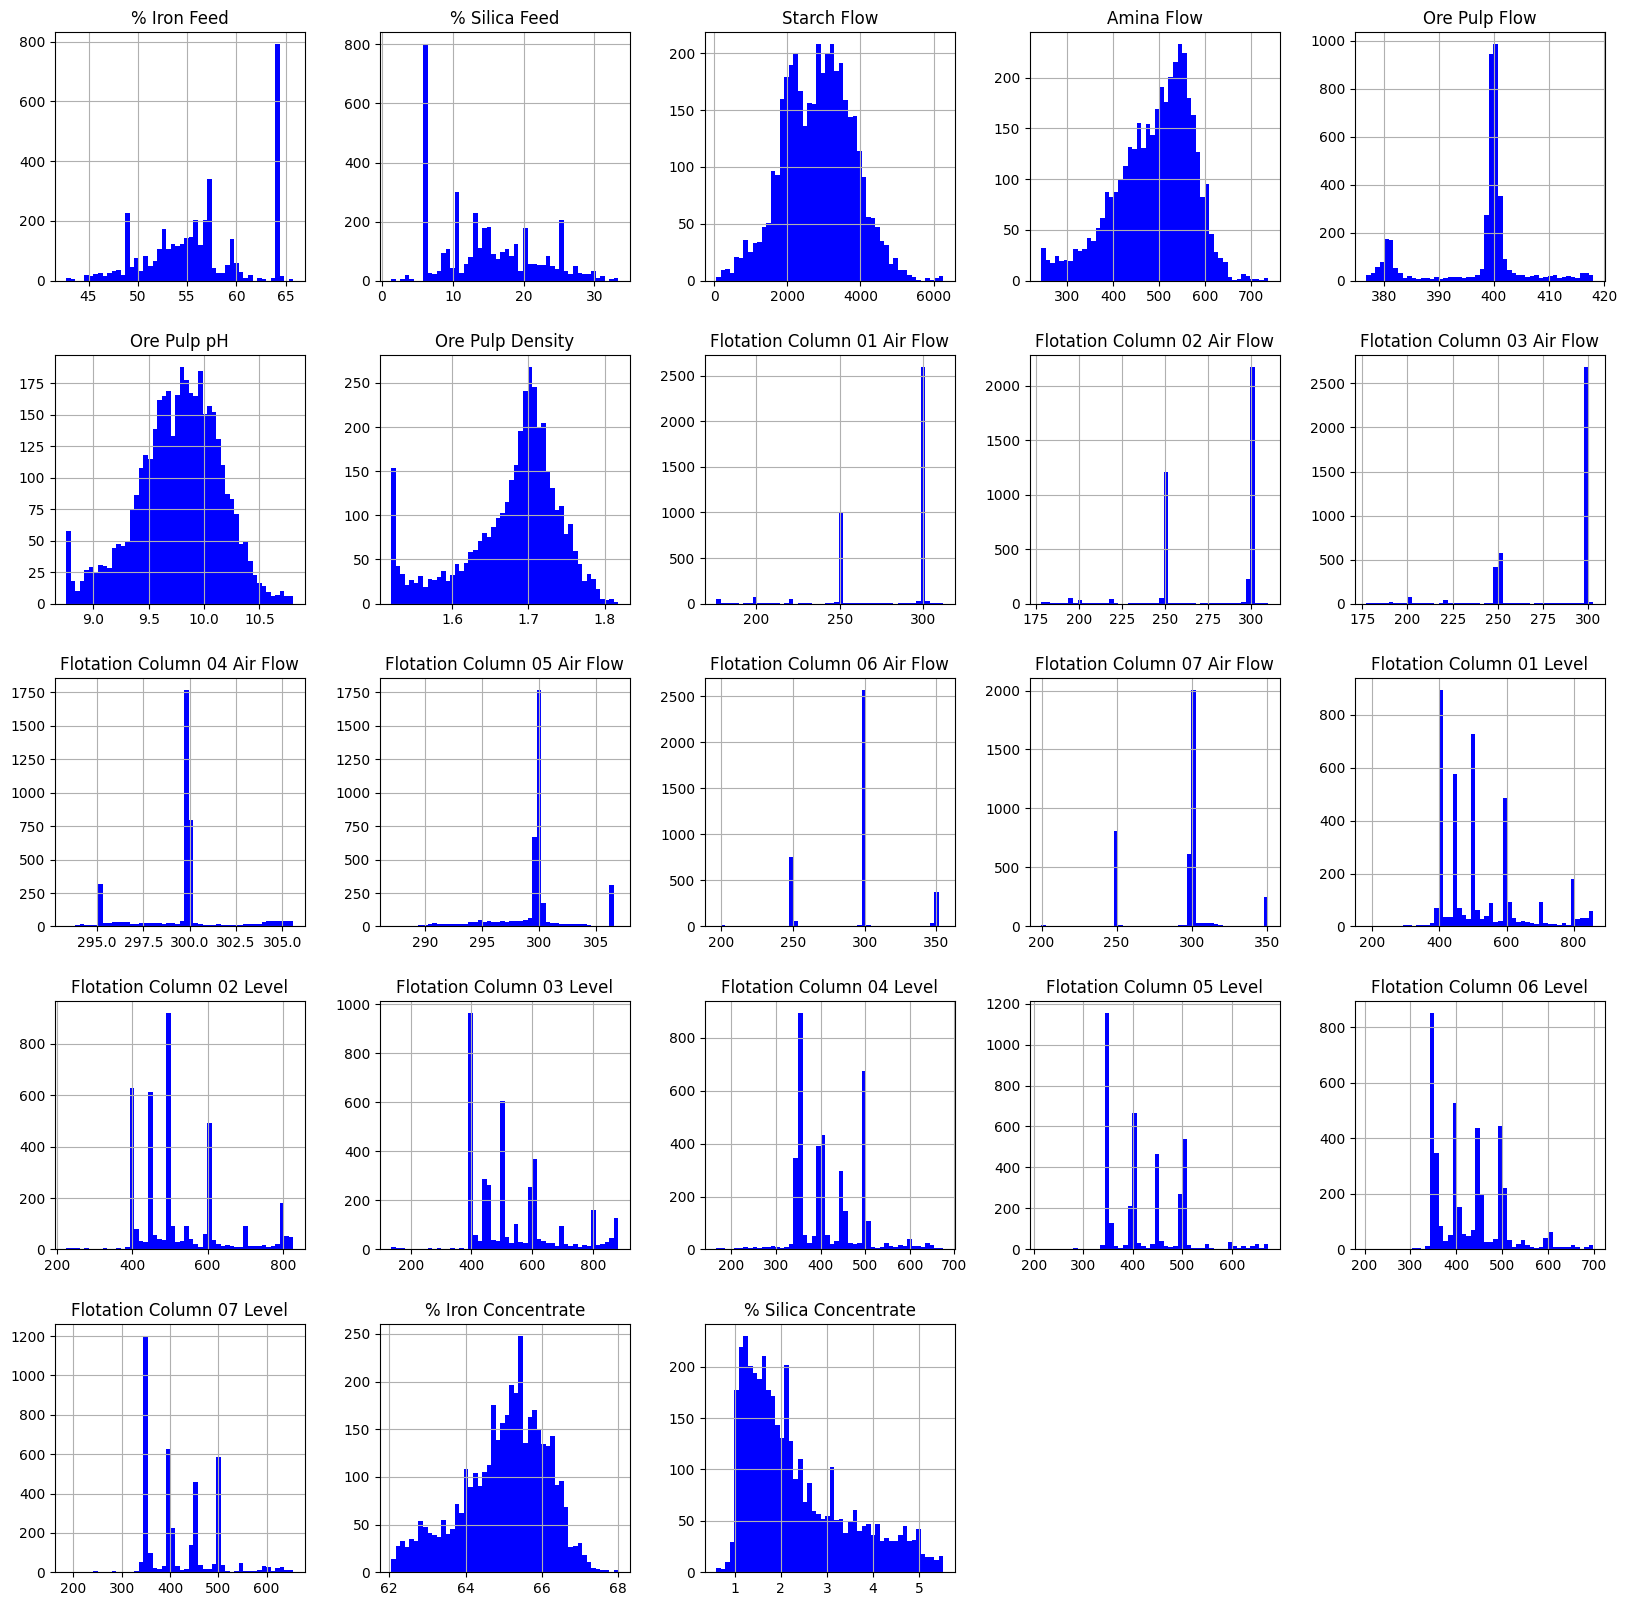

In [14]:
silica_df.hist(bins=50, figsize=(20,20), color="blue")

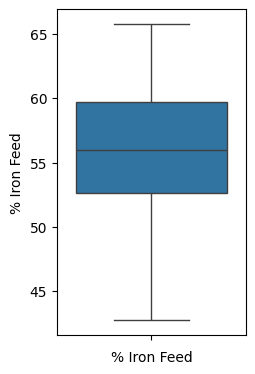

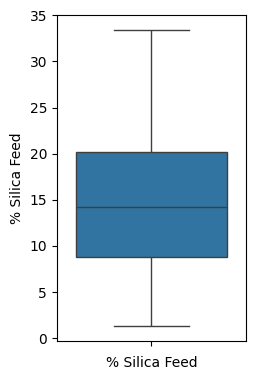

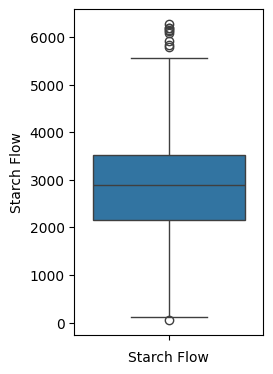

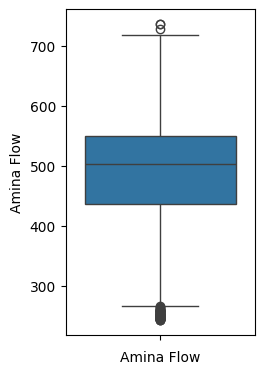

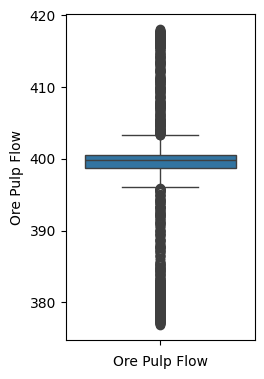

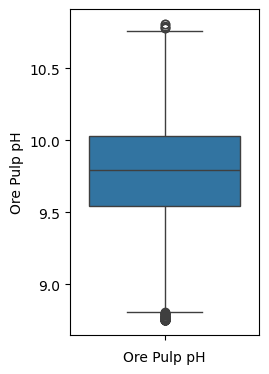

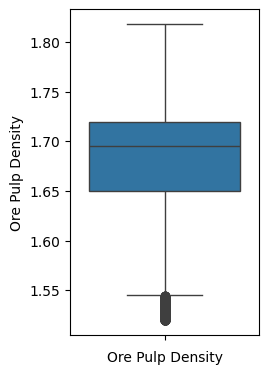

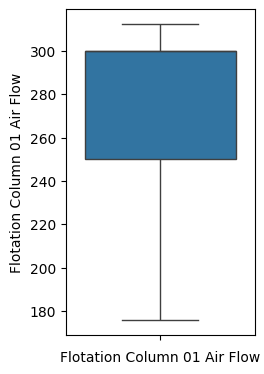

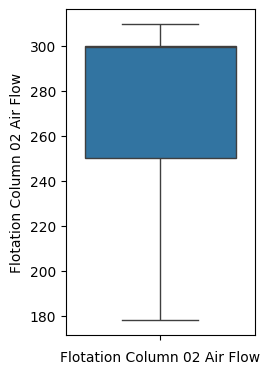

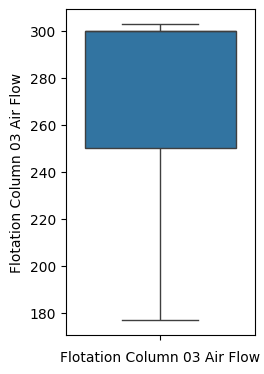

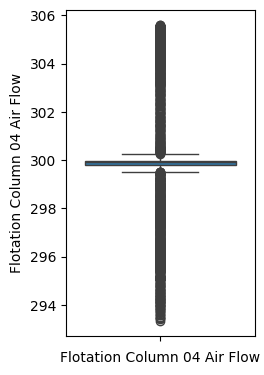

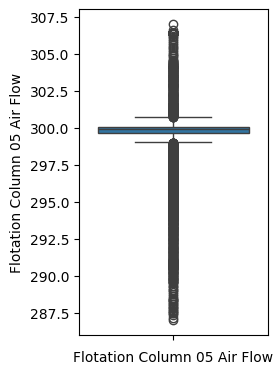

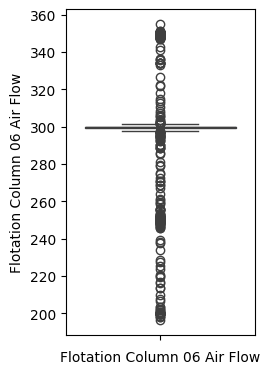

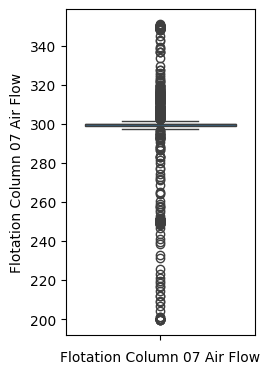

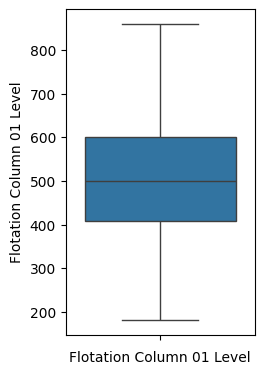

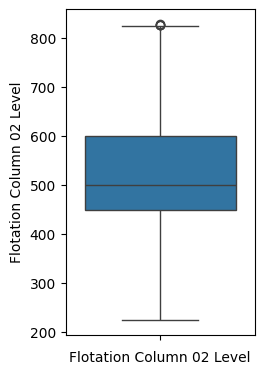

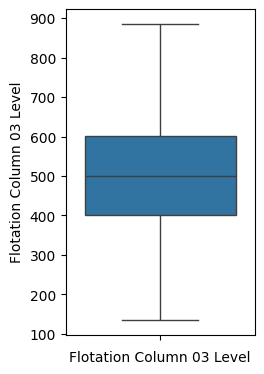

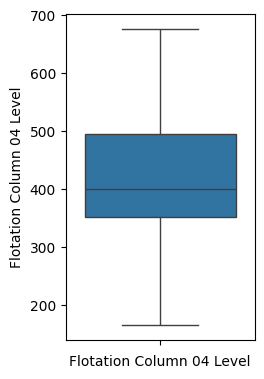

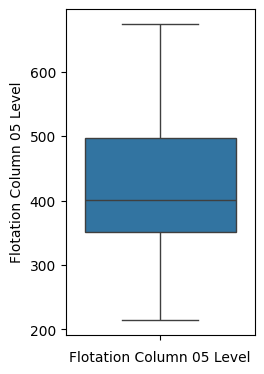

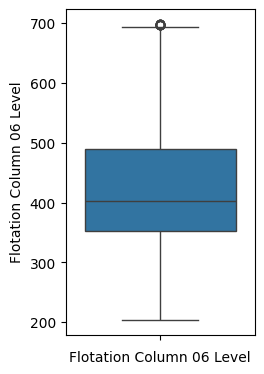

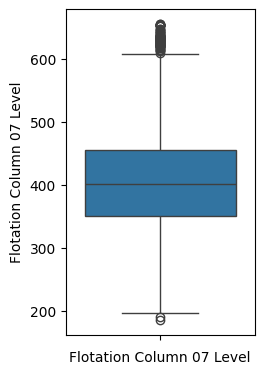

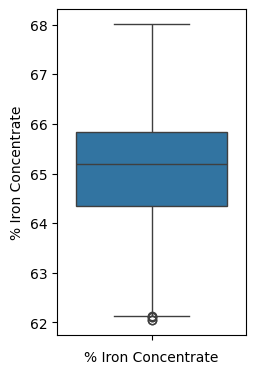

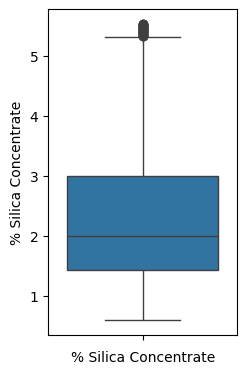

In [15]:
numerical_features = silica_df.select_dtypes(include=['float64', 'int64']).columns

plotnumber =1
for numerical_feature in numerical_features:
    plt.figure(figsize=(20,60), facecolor='white')
    ax = plt.subplot(12,7,plotnumber)
    sns.boxplot(silica_df[numerical_feature])
    plt.xlabel(numerical_feature)
    plotnumber+=1
    plt.show()

# Data Preprocessing

## Min Max Scaler

In [16]:
def min_max_scaler(X):
    scaler = MinMaxScaler()
    scaled_values = scaler.fit_transform(X)
    scaled_df = pd.DataFrame(data=scaled_values, columns=X.columns, index=X.index)
    return scaled_df

## Standard Scaler

In [17]:
def standard_scaler(X):
    scaler = StandardScaler()
    scaled_values = scaler.fit_transform(X)
    scaled_df = pd.DataFrame(data=scaled_values, columns=X.columns, index=X.index)
    return scaled_df

## Robust Scaler

In [18]:
def robust_scaler(X):
    scaler = RobustScaler()
    scaled_values = scaler.fit_transform(X)
    scaled_df = pd.DataFrame(data=scaled_values, columns=X.columns, index=X.index)
    return scaled_df

## Correlation Feature Selection

In [19]:
def select_features_correlation(df, threshold=0.1):
    # Extract target variable column name (last column)
    target_column = df.columns[-1]

    # Calculate correlation matrix
    corr_matrix = df.corr()

    # Select features with correlation coefficient above the threshold
    selected_features_df = corr_matrix[target_column][abs(corr_matrix[target_column]) > threshold].index.tolist()

    return selected_features_df

selected = select_features_correlation(silica_df)
print(selected)

['Amina Flow', 'Ore Pulp pH', 'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow', 'Flotation Column 03 Air Flow', 'Flotation Column 04 Level', 'Flotation Column 05 Level', 'Flotation Column 06 Level', 'Flotation Column 07 Level', '% Iron Concentrate', '% Silica Concentrate']


## Cross Validation

In [20]:
def cross_validate_model(model, x, y, n_splits=5):
    timesplit = TimeSeriesSplit(n_splits=n_splits)

    all_predictions = []
    all_actual_values = []
    mse_values = []
    rmse_values = []
    r2_values = []

    for train_index, test_index in timesplit.split(x):
        X_train, X_test = x[train_index], x[test_index]
        Y_train, Y_test = y[train_index], y[test_index]

        # Fit the model
        model.fit(X_train, Y_train)

        # Make predictions
        y_pred = model.predict(X_test)

        # Store predictions and actual values for each fold
        all_predictions.append(y_pred)
        all_actual_values.append(Y_test)

        # Evaluate the model
        model_mse = mean_squared_error(Y_test, y_pred)
        model_rmse = np.sqrt(model_mse)
        model_r2score = r2_score(Y_test, y_pred)

        mse_values.append(model_mse)
        rmse_values.append(model_rmse)
        r2_values.append(model_r2score)

    # Concat all array
    all_predictions = np.concatenate(all_predictions, axis=0)
    all_actual_values = np.concatenate(all_actual_values, axis=0)

    # Calculate average metrics across folds
    average_rmse = np.mean(rmse_values)
    average_mse = np.mean(mse_values)
    average_r2 = np.mean(r2_values)
    variance = np.var(mse_values)

    return average_mse, average_rmse, average_r2, all_predictions, all_actual_values, variance

In [21]:
def lstm_cross_validate_model(model, x, y, timesplit, epochs=20):
    # Perform cross-validation
    all_predictions = []
    all_actual_values = []
    training_loss_history = []
    mse_values = []
    rmse_values = []
    r2_values = []

    for train_index, test_index in timesplit.split(x):
        X_train, X_test = x[train_index], x[test_index]
        Y_train, Y_test = y[train_index], y[test_index]

        # Reshape data for LSTM
        X_train_lstm = np.reshape(X_train, (X_train.shape[0], X_train.shape[1],X_train.shape[2]))
        X_test_lstm = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

        # Train the model and store training loss history
        history = model.fit(X_train_lstm, Y_train, batch_size=32, epochs=epochs, verbose=1)
        training_loss_history.append(history.history['loss'])

        # Make predictions
        lstm_y_pred = model.predict(X_test_lstm)

        # Reshape Y_test to match lstm_y_pred shape
        Y_test_reshaped = np.squeeze(Y_test)

        # Store predictions and actual values
        all_predictions.append(lstm_y_pred)
        all_actual_values.append(Y_test_reshaped)

        # Evaluate the model
        model_mse = mean_squared_error(Y_test_reshaped, lstm_y_pred)
        model_rmse = np.sqrt(model_mse)
        model_r2score = r2_score(Y_test_reshaped, lstm_y_pred)

        mse_values.append(model_mse)
        rmse_values.append(model_rmse)
        r2_values.append(model_r2score)

    # Concat all array
    all_predictions = np.concatenate(all_predictions, axis=0)
    all_actual_values = np.concatenate(all_actual_values, axis=0)

    # Calculate average metrics across folds
    average_rmse = np.mean(rmse_values)
    average_mse = np.mean(mse_values)
    average_r2 = np.mean(r2_values)
    variance = np.var(mse_values)

    return average_mse, average_rmse, average_r2, all_predictions, all_actual_values, variance


## Plot Actual Predicted

In [22]:
def plot_predictions_vs_actual(all_predictions, all_actual_values, xlabel='Samples', ylabel='% Silica Concentrate', title="", figsize=(10, 6)):
    plt.figure(figsize=figsize)
    plt.plot(all_actual_values, label='Actual')
    plt.plot(all_predictions, label='Predicted')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()

## Plot Bar Chart

In [23]:
def plot_bar_chart(data, labels, title, xlabel, ylabel):
    plt.figure(figsize=(8, 6))
    bars = plt.bar(labels, data, color=['skyblue', 'orange', 'lightgreen', 'plum'])
    plt.title(title, fontsize=16, fontweight='bold', color='navy')
    plt.xlabel(xlabel, fontsize=14, fontweight='bold', color='black')
    plt.ylabel(ylabel, fontsize=14, fontweight='bold', color='black')
    plt.xticks(fontsize=12, fontweight='bold', color='darkslategray')
    plt.yticks(fontsize=12, fontweight='bold', color='darkslategray')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    for bar, value in zip(bars, data):
        plt.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height(),
                 round(value, 10),
                 ha='center', va='bottom',
                 fontsize=10, fontweight='bold', color='brown')

    plt.tight_layout()
    plt.show()


# Part A

## Random Forest Regressor

### Base

In [24]:
rfr_base_model = RandomForestRegressor(random_state=1, max_depth=5)
df = silica_df
# Split your data into features and target variable
X = df.drop(columns=[df.columns[-1]])
y = df.iloc[:, -1]  # Select the last column as the target variable

# Perform cross-validation using cross_validate_model
rfr_base_average_mse, rfr_base_average_rmse, rfr_base_average_r2, rfr_base_all_predictions, rfr_base_all_actual_values, rfr_base_variance = cross_validate_model(rfr_base_model, X.values, y.values)

print("Random Forest Regressor")
print("Average Bias: ", rfr_base_average_mse)
print("Variance: ", rfr_base_variance)
print("Average RMSE: ", rfr_base_average_rmse)
print("Average R2 Score: ", rfr_base_average_r2)

Random Forest Regressor
Average Bias:  0.4969610388679815
Variance:  0.0143884937199184
Average RMSE:  0.7003885252870894
Average R2 Score:  0.5309722441989948


### MinMaxScaler

In [25]:
rfr_minmax_model = RandomForestRegressor(random_state=1, max_depth=5)
df = silica_df
# Split your data into features and target variable
X = df.drop(columns=[df.columns[-1]])
X = min_max_scaler(X)
y = df.iloc[:, -1]  # Select the last column as the target variable

# Perform cross-validation using cross_validate_model
rfr_minmax_average_mse, rfr_minmax_average_rmse, rfr_minmax_average_r2, rfr_minmax_all_predictions, rfr_minmax_all_actual_values, rfr_minmax_variance = cross_validate_model(rfr_minmax_model, X.values, y.values)

print("Random Forest Regressor")
print("Average Bias: ", rfr_minmax_average_mse)
print("Variance: ", rfr_minmax_variance)
print("Average RMSE: ", rfr_minmax_average_rmse)
print("Average R2 Score: ", rfr_minmax_average_r2)

Random Forest Regressor
Average Bias:  0.4969396404394601
Variance:  0.014331698885363672
Average RMSE:  0.7003878464641018
Average R2 Score:  0.5309661453390845


### StandardScaler

In [26]:
rfr_standard_model = RandomForestRegressor(random_state=1, max_depth=5)
df = silica_df
# Split your data into features and target variable
X = df.drop(columns=[df.columns[-1]])
X = standard_scaler(X)
y = df.iloc[:, -1]  # Select the last column as the target variable

# Perform cross-validation using cross_validate_model
rfr_standard_average_mse, rfr_standard_average_rmse, rfr_standard_average_r2, rfr_standard_all_predictions, rfr_standard_all_actual_values, rfr_standard_variance = cross_validate_model(rfr_standard_model, X.values, y.values)

print("Random Forest Regressor")
print("Average Bias: ", rfr_standard_average_mse)
print("Variance: ", rfr_standard_variance)
print("Average RMSE: ", rfr_standard_average_rmse)
print("Average R2 Score: ", rfr_standard_average_r2)

Random Forest Regressor
Average Bias:  0.49679217734549574
Variance:  0.014262348933516033
Average RMSE:  0.70030213482619
Average R2 Score:  0.5310687844323533


### Robust Scaler

In [27]:
rfr_robust_model = RandomForestRegressor(random_state=1, max_depth=5)
df = silica_df
# Split your data into features and target variable
X = df.drop(columns=[df.columns[-1]])
X = robust_scaler(X)
y = df.iloc[:, -1]  # Select the last column as the target variable

# Perform cross-validation using cross_validate_model
rfr_robust_average_mse, rfr_robust_average_rmse, rfr_robust_average_r2, rfr_robust_all_predictions, rfr_robust_all_actual_values, rfr_robust_variance = cross_validate_model(rfr_robust_model, X.values, y.values)

print("Random Forest Regressor")
print("Average Bias: ", rfr_robust_average_mse)
print("Variance: ", rfr_robust_variance)
print("Average RMSE: ", rfr_robust_average_rmse)
print("Average R2 Score: ", rfr_robust_average_r2)

Random Forest Regressor
Average Bias:  0.4968818935685107
Variance:  0.01436996295055538
Average RMSE:  0.7003366996149214
Average R2 Score:  0.5310639201745652


### Comparison Scaler

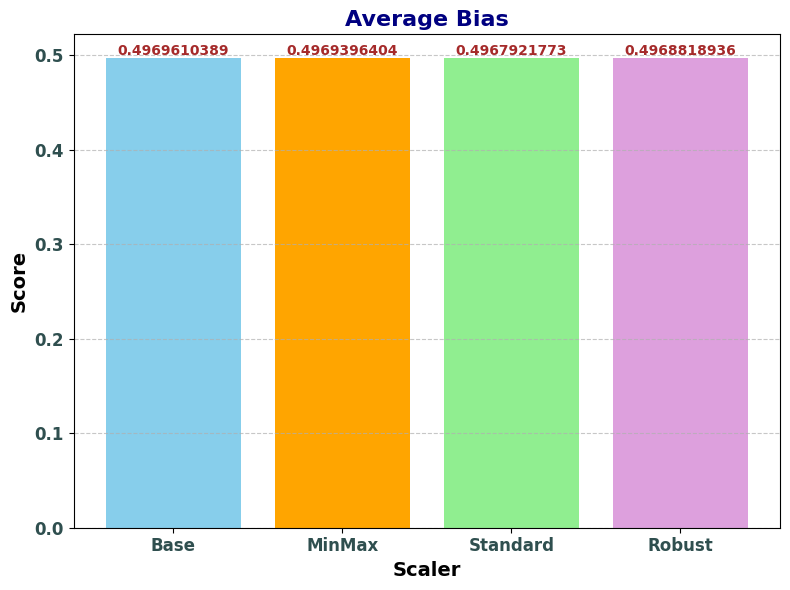

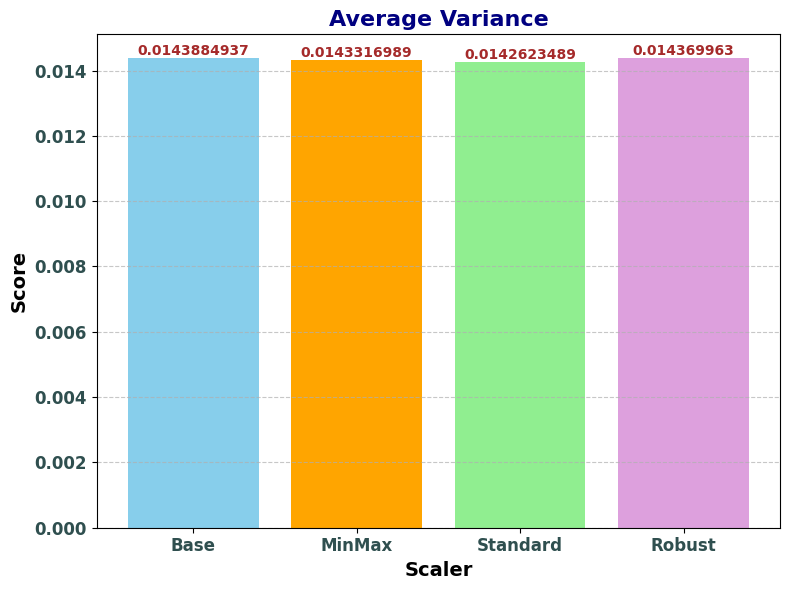

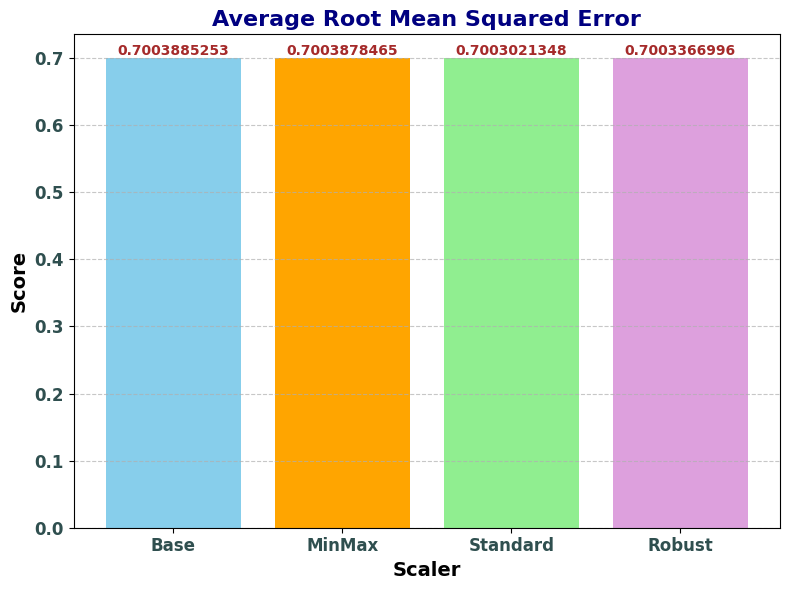

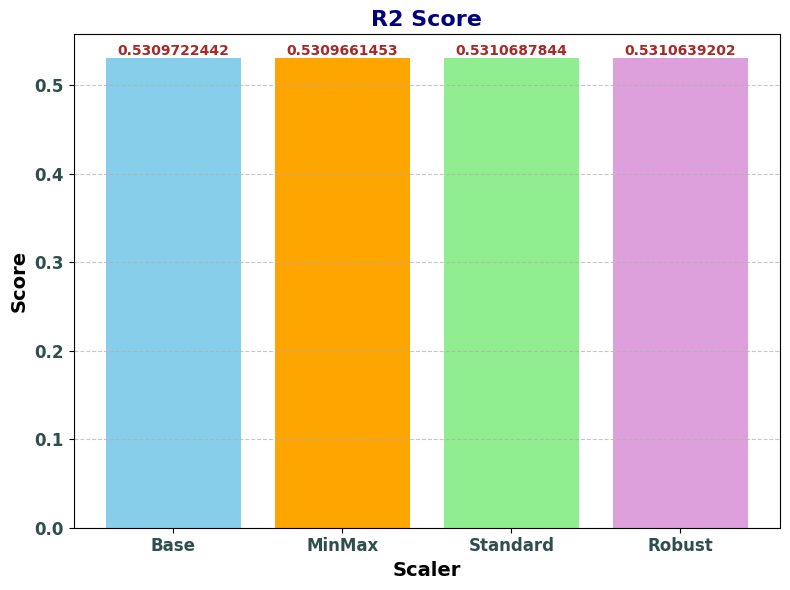

In [28]:
bias = [rfr_base_average_mse, rfr_minmax_average_mse, rfr_standard_average_mse, rfr_robust_average_mse]
variance = [rfr_base_variance, rfr_minmax_variance, rfr_standard_variance, rfr_robust_variance]
rmse = [rfr_base_average_rmse, rfr_minmax_average_rmse, rfr_standard_average_rmse, rfr_robust_average_rmse]
r2 = [rfr_base_average_r2, rfr_minmax_average_r2, rfr_standard_average_r2, rfr_robust_average_r2]
labels = ['Base', 'MinMax', 'Standard', 'Robust']

plot_bar_chart(bias, labels, 'Average Bias', 'Scaler', 'Score')
plot_bar_chart(variance, labels, 'Average Variance', 'Scaler', 'Score')
plot_bar_chart(rmse, labels, 'Average Root Mean Squared Error', 'Scaler', 'Score')
plot_bar_chart(r2, labels, 'R2 Score', 'Scaler', 'Score')


###  Correlation, StandardScaler

In [26]:
rfr_standard_correlation_model = RandomForestRegressor(random_state=1, max_depth=5)
df = silica_df
selected_features = select_features_correlation(df)
df = df[selected_features]

# Split your data into features and target variable
X = df.drop(columns=[df.columns[-1]])
X = standard_scaler(X)
y = df.iloc[:, -1]  # Select the last column as the target variable

# Perform cross-validation using cross_validate_model
rfr_standard_correlation_average_mse, rfr_standard_correlation_average_rmse, rfr_standard_correlation_average_r2, rfr_standard_correlation_all_predictions, rfr_standard_correlation_all_actual_values, rfr_standard_correlation_variance = cross_validate_model(rfr_standard_correlation_model, X.values, y.values)

print("Random Forest Regressor")
print("Average Bias: ", rfr_standard_correlation_average_mse)
print("Variance: ", rfr_standard_correlation_variance)
print("Average RMSE: ", rfr_standard_correlation_average_rmse)
print("Average R2 Score: ", rfr_standard_correlation_average_r2)

Random Forest Regressor
Average Bias:  0.4504539039010189
Variance:  0.013302240409727018
Average RMSE:  0.6659380129887544
Average R2 Score:  0.5645988782543542


### Plot

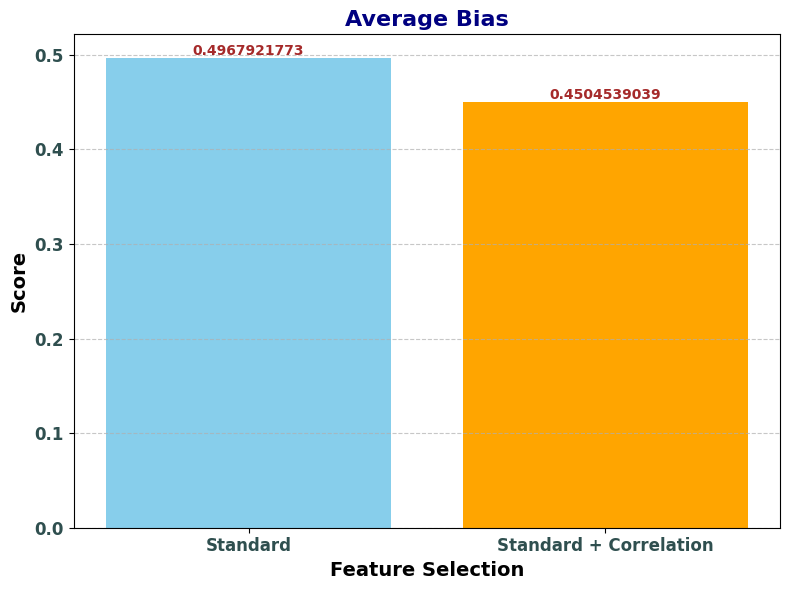

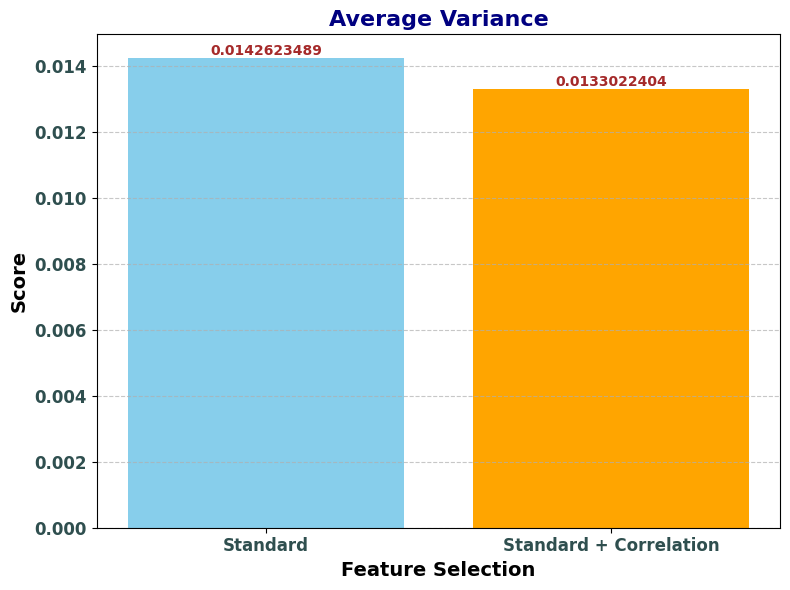

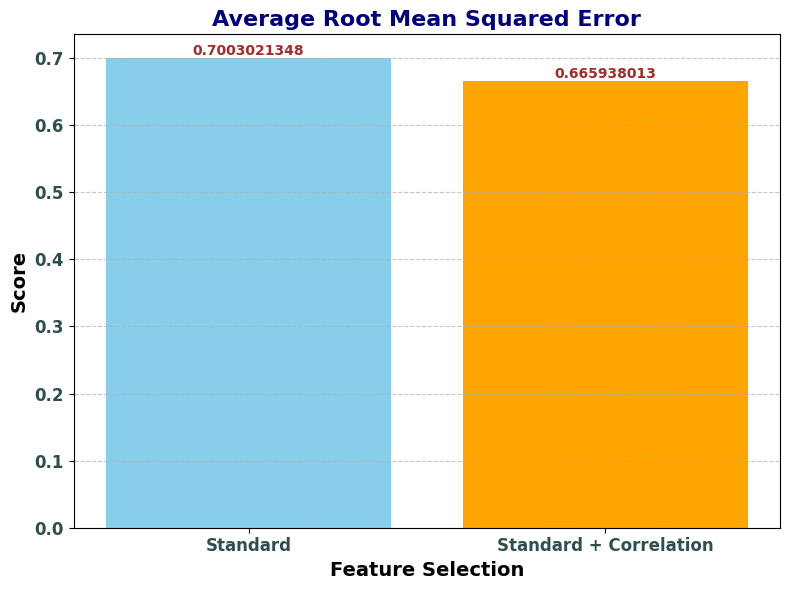

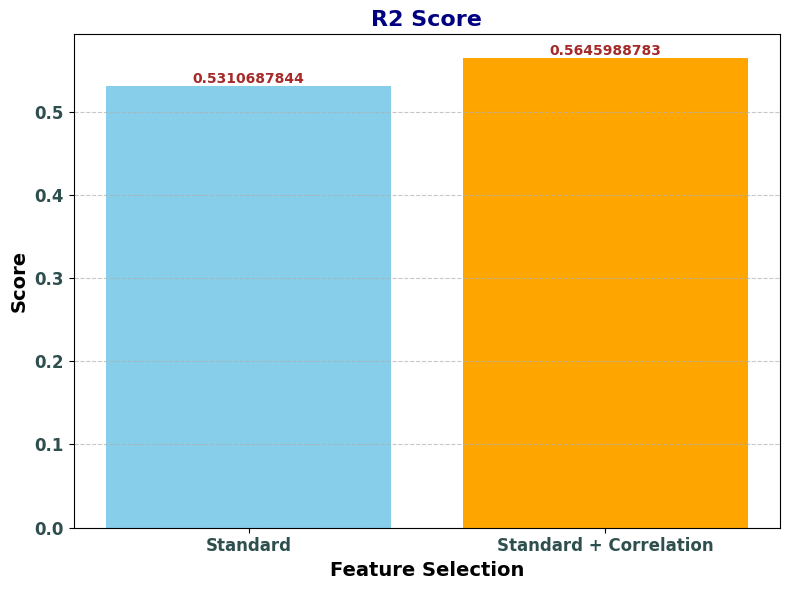

In [30]:
bias = [rfr_standard_average_mse, rfr_standard_correlation_average_mse]
variance = [rfr_standard_variance, rfr_standard_correlation_variance]
rmse = [rfr_standard_average_rmse, rfr_standard_correlation_average_rmse]
r2 = [ rfr_standard_average_r2, rfr_standard_correlation_average_r2]
labels = ['Standard', 'Standard + Correlation']

plot_bar_chart(bias, labels, 'Average Bias', 'Feature Selection', 'Score')
plot_bar_chart(variance, labels, 'Average Variance', 'Feature Selection', 'Score')
plot_bar_chart(rmse, labels, 'Average Root Mean Squared Error', 'Feature Selection', 'Score')
plot_bar_chart(r2, labels, 'R2 Score', 'Feature Selection', 'Score')

## Support Vector Regressor

### Base

In [31]:
svr_base_model = SVR()
df = silica_df
# Split your data into features and target variable
X = df.drop(columns=[df.columns[-1]])
y = df.iloc[:, -1]  # Select the last column as the target variable

# Perform cross-validation using cross_validate_model
svr_base_average_mse, svr_base_average_rmse, svr_base_average_r2, svr_base_all_predictions, svr_base_all_actual_values, svr_base_variance = cross_validate_model(svr_base_model, X.values, y.values)

print("Support Vector Regressor")
print("Average Bias: ", svr_base_average_mse)
print("Variance: ", svr_base_variance)
print("Average RMSE: ", svr_base_average_rmse)
print("Average R2 Score: ", svr_base_average_r2)

Support Vector Regressor
Average Bias:  1.3623347400186234
Variance:  0.2547849923494255
Average RMSE:  1.1498046868993013
Average R2 Score:  -0.22999015072456497


### MinMaxScaler

In [32]:
svr_minmax_model = SVR()
df = silica_df
# Split your data into features and target variable
X = df.drop(columns=[df.columns[-1]])
X = min_max_scaler(X)
y = df.iloc[:, -1]  # Select the last column as the target variable

# Perform cross-validation using cross_validate_model
svr_minmax_average_mse, svr_minmax_average_rmse, svr_minmax_average_r2, svr_minmax_all_predictions, svr_minmax_all_actual_values, svr_minmax_variance = cross_validate_model(svr_minmax_model, X.values, y.values)

print("Support Vector Regressor")
print("Average Bias: ", svr_minmax_average_mse)
print("Variance: ", svr_minmax_variance)
print("Average RMSE: ", svr_minmax_average_rmse)
print("Average R2 Score: ", svr_minmax_average_r2)

Support Vector Regressor
Average Bias:  0.5930084877521101
Variance:  0.037361340803436366
Average RMSE:  0.761168552093834
Average R2 Score:  0.45971347009561414


### StandardScaler

In [33]:
svr_standard_model = SVR()
df = silica_df
# Split your data into features and target variable
X = df.drop(columns=[df.columns[-1]])
X = standard_scaler(X)
y = df.iloc[:, -1]  # Select the last column as the target variable

# Perform cross-validation using cross_validate_model
svr_standard_average_mse, svr_standard_average_rmse, svr_standard_average_r2, svr_standard_aa_predictions, svr_standard_all_actual_values, svr_standard_variance = cross_validate_model(svr_standard_model, X.values, y.values)

print("Support Vector Regressor")
print("Average Bias: ", svr_standard_average_mse)
print("Variance: ", svr_standard_variance)
print("Average RMSE: ", svr_standard_average_rmse)
print("Average R2 Score: ", svr_standard_average_r2)

Support Vector Regressor
Average Bias:  0.6343350289864047
Variance:  0.03492772786019683
Average RMSE:  0.7889314440398156
Average R2 Score:  0.4169538506405214


### Robust Scaler

In [34]:
svr_robust_model = SVR()
df = silica_df
# Split your data into features and target variable
X = df.drop(columns=[df.columns[-1]])
X = robust_scaler(X)
y = df.iloc[:, -1]  # Select the last column as the target variable

# Perform cross-validation using cross_validate_model
svr_robust_average_mse, svr_robust_average_rmse, svr_robust_average_r2, svr_robust_all_predictions, svr_robust_all_actual_values, svr_robust_variance = cross_validate_model(svr_robust_model, X.values, y.values)

print("Support Vector Regressor")
print("Average Bias: ", svr_robust_average_mse)
print("Variance: ", svr_robust_variance)
print("Average RMSE: ", svr_robust_average_rmse)
print("Average R2 Score: ", svr_robust_average_r2)

Support Vector Regressor
Average Bias:  1.101523011409971
Variance:  0.15106630813223226
Average RMSE:  1.0331545340732375
Average R2 Score:  -0.013985254527356106


### Plot

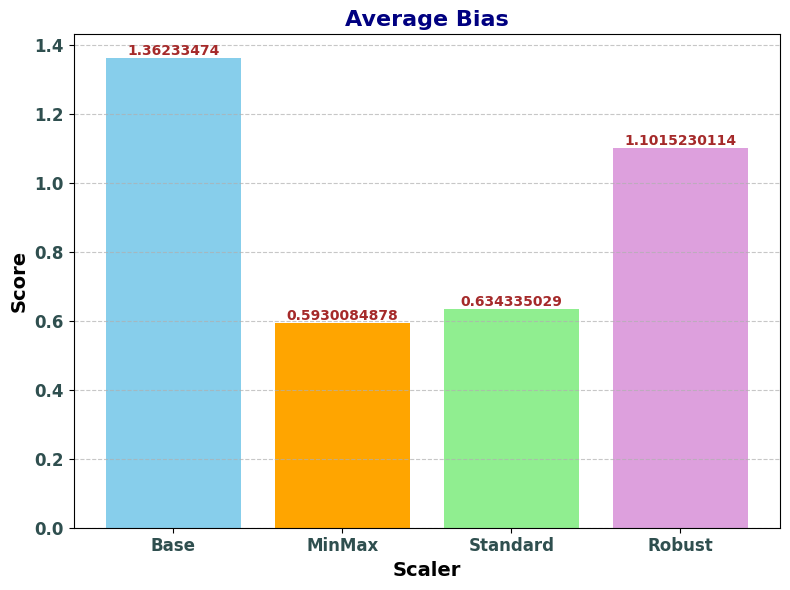

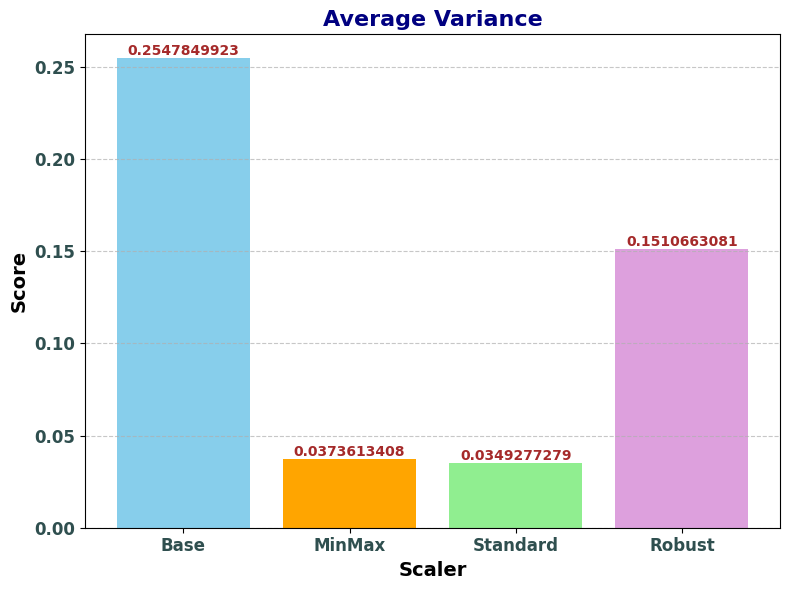

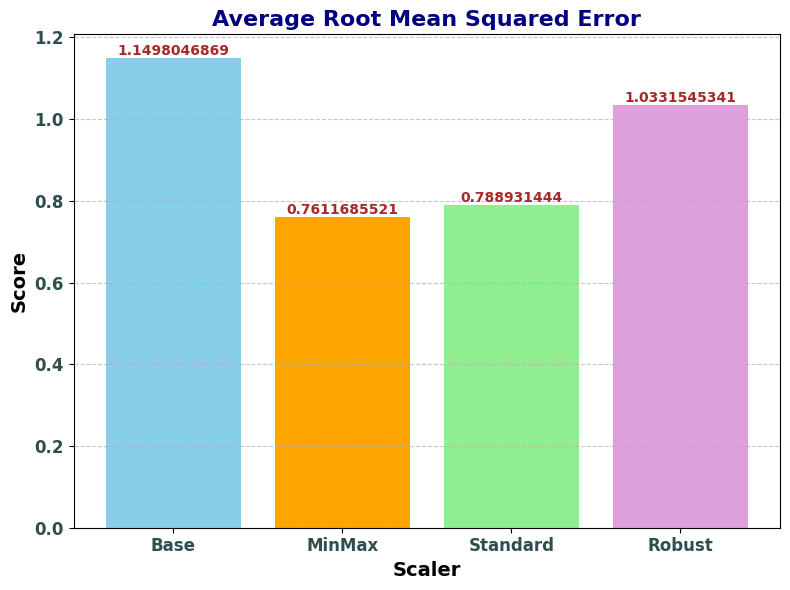

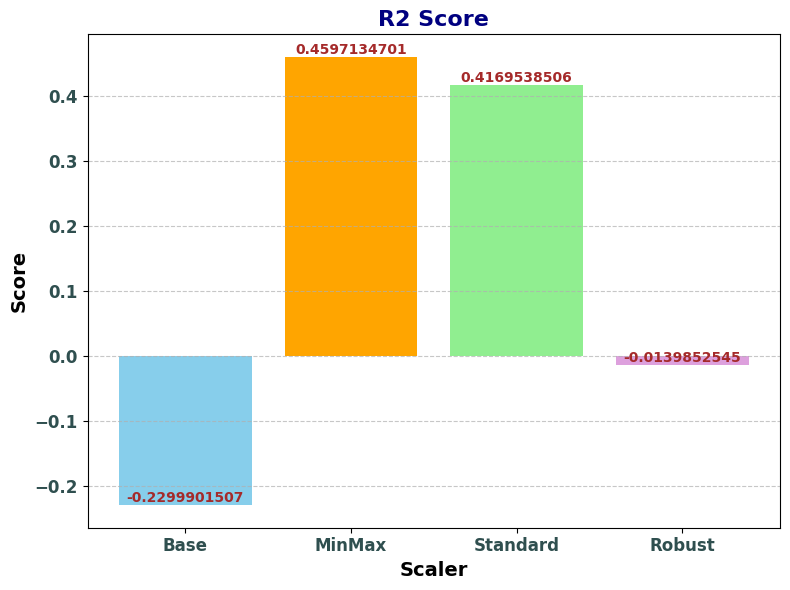

In [35]:
bias = [svr_base_average_mse, svr_minmax_average_mse, svr_standard_average_mse, svr_robust_average_mse]
variance = [svr_base_variance, svr_minmax_variance, svr_standard_variance, svr_robust_variance]
rmse = [svr_base_average_rmse, svr_minmax_average_rmse, svr_standard_average_rmse, svr_robust_average_rmse]
r2 = [svr_base_average_r2, svr_minmax_average_r2, svr_standard_average_r2, svr_robust_average_r2]
labels = ['Base', 'MinMax', 'Standard', 'Robust']

plot_bar_chart(bias, labels, 'Average Bias', 'Scaler', 'Score')
plot_bar_chart(variance, labels, 'Average Variance', 'Scaler', 'Score')
plot_bar_chart(rmse, labels, 'Average Root Mean Squared Error', 'Scaler', 'Score')
plot_bar_chart(r2, labels, 'R2 Score', 'Scaler', 'Score')

### MinMax Scaler, Correlation

In [27]:
svr_minmax_correlation_model = SVR()
df = silica_df
selected_features = select_features_correlation(df)
df = df[selected_features]

# Split your data into features and target variable
X = df.drop(columns=[df.columns[-1]])
X = min_max_scaler(X)
y = df.iloc[:, -1]  # Select the last column as the target variable

# Perform cross-validation using cross_validate_model
svr_minmax_correlation_average_mse, svr_minmax_correlation_average_rmse, svr_minmax_correlation_average_r2, svr_minmax_correlation_all_predictions, svr_minmax_correlation_all_actual_values, svr_minmax_correlation_variance = cross_validate_model(svr_minmax_correlation_model, X.values, y.values)

print("Support Vector Regressor")
print("Average Bias: ", svr_minmax_correlation_average_mse)
print("Variance: ", svr_minmax_correlation_variance)
print("Average RMSE: ", svr_minmax_correlation_average_rmse)
print("Average R2 Score: ", svr_minmax_correlation_average_r2)

Support Vector Regressor
Average Bias:  0.5103123437389971
Variance:  0.030955642867267524
Average RMSE:  0.7052313053236355
Average R2 Score:  0.5253246139221351


### Plot

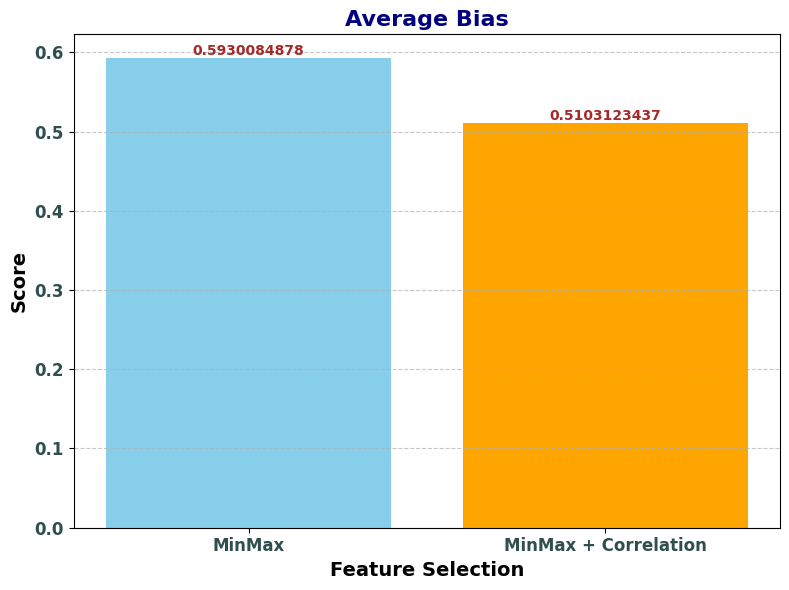

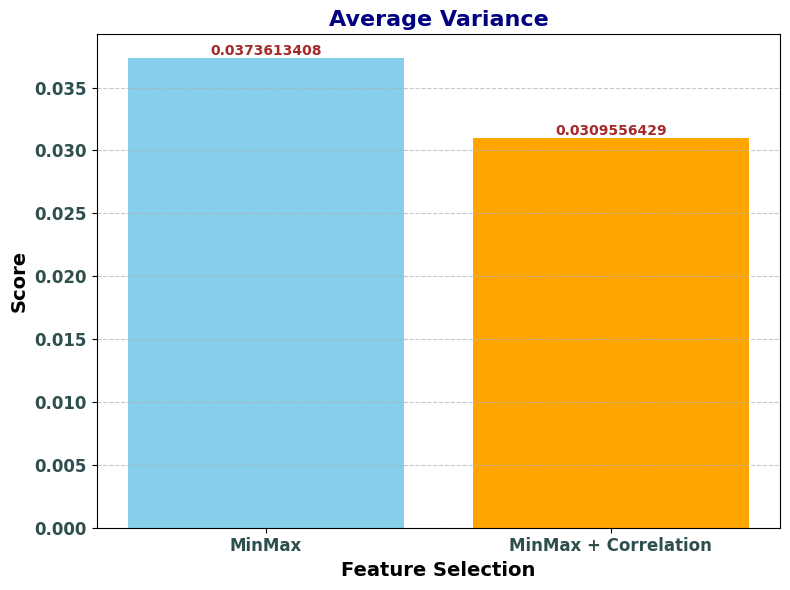

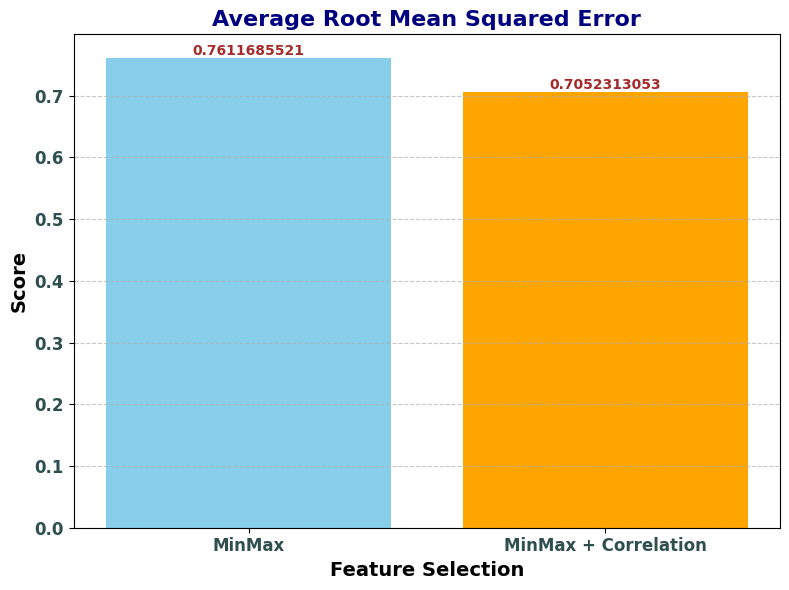

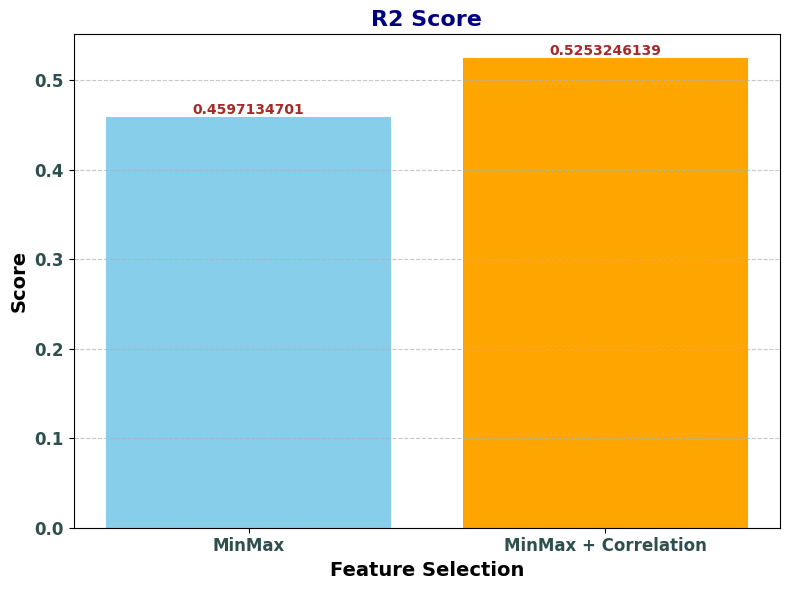

In [37]:
bias = [svr_minmax_average_mse, svr_minmax_correlation_average_mse]
variance = [svr_minmax_variance, svr_minmax_correlation_variance]
rmse = [svr_minmax_average_rmse, svr_minmax_correlation_average_rmse]
r2 = [ svr_minmax_average_r2, svr_minmax_correlation_average_r2]
labels = ['MinMax', 'MinMax + Correlation']

plot_bar_chart(bias, labels, 'Average Bias', 'Feature Selection', 'Score')
plot_bar_chart(variance, labels, 'Average Variance', 'Feature Selection', 'Score')
plot_bar_chart(rmse, labels, 'Average Root Mean Squared Error', 'Feature Selection', 'Score')
plot_bar_chart(r2, labels, 'R2 Score', 'Feature Selection', 'Score')

## Gradient Boosting Regressor

### Base

In [38]:
gbr_base_model = GradientBoostingRegressor(random_state=42)

df = silica_df
# Split your data into features and target variable
X = df.drop(columns=[df.columns[-1]])
y = df.iloc[:, -1]  # Select the last column as the target variable

# Perform cross-validation using cross_validate_model
gbr_base_average_mse, gbr_base_average_rmse, gbr_base_average_r2, gbr_base_all_predictions, gbr_base_all_actual_values, gbr_base_variance = cross_validate_model(gbr_base_model, X.values, y.values)

print("Gradient Boosting Regressor")
print("Average Bias: ", gbr_base_average_mse)
print("Variance: ", gbr_base_variance)
print("Average RMSE: ", gbr_base_average_rmse)
print("Average R2 Score: ", gbr_base_average_r2)

Gradient Boosting Regressor
Average Bias:  0.538872639118067
Variance:  0.039135584702320696
Average RMSE:  0.7239134469431189
Average R2 Score:  0.5035863186444167


### MinMaxScaler

In [39]:
gbr_minmax_model = GradientBoostingRegressor(random_state=42)

df = silica_df
# Split your data into features and target variable
X = df.drop(columns=[df.columns[-1]])
X = min_max_scaler(X)
y = df.iloc[:, -1]  # Select the last column as the target variable

# Perform cross-validation using cross_validate_model
gbr_minmax_average_mse, gbr_minmax_average_rmse, gbr_minmax_average_r2, gbr_minmax_all_predictions, gbr_minmax_all_actual_values, gbr_minmax_variance = cross_validate_model(gbr_minmax_model, X.values, y.values)

print("Gradient Boosting Regressor")
print("Average Bias: ", gbr_minmax_average_mse)
print("Variance: ", gbr_minmax_variance)
print("Average RMSE: ", gbr_minmax_average_rmse)
print("Average R2 Score: ", gbr_minmax_average_r2)

Gradient Boosting Regressor
Average Bias:  0.5388689206599139
Variance:  0.03873916334097112
Average RMSE:  0.724011218940266
Average R2 Score:  0.5034153495221092


### StandardScaler

In [40]:
gbr_standard_model = GradientBoostingRegressor(random_state=42)

df = silica_df
# Split your data into features and target variable
X = df.drop(columns=[df.columns[-1]])
X = standard_scaler(X)
y = df.iloc[:, -1]  # Select the last column as the target variable

# Perform cross-validation using cross_validate_model
gbr_standard_average_mse, gbr_standard_average_rmse, gbr_standard_average_r2, gbr_standard_all_predictions, gbr_standard_all_actual_values, gbr_standard_variance = cross_validate_model(gbr_standard_model, X.values, y.values)

print("Gradient Boosting Regressor")
print("Average Bias: ", gbr_standard_average_mse)
print("Variance: ", gbr_standard_variance)
print("Average RMSE: ", gbr_standard_average_rmse)
print("Average R2 Score: ", gbr_standard_average_r2)

Gradient Boosting Regressor
Average Bias:  0.5380337046648962
Variance:  0.03890870959087903
Average RMSE:  0.7233791050177365
Average R2 Score:  0.5042171968354348


### Robust Scaler

In [41]:
gbr_robust_model = GradientBoostingRegressor(random_state=42)

df = silica_df
# Split your data into features and target variable
X = df.drop(columns=[df.columns[-1]])
X = robust_scaler(X)
y = df.iloc[:, -1]  # Select the last column as the target variable

# Perform cross-validation using cross_validate_model
gbr_robust_average_mse, gbr_robust_average_rmse, gbr_robust_average_r2, gbr_robust_all_predictions, gbr_robust_all_actual_values, gbr_robust_variance = cross_validate_model(gbr_robust_model, X.values, y.values)

print("Gradient Boosting Regressor")
print("Average Bias: ", gbr_robust_average_mse)
print("Variance: ", gbr_robust_variance)
print("Average RMSE: ", gbr_robust_average_rmse)
print("Average R2 Score: ", gbr_robust_average_r2)

Gradient Boosting Regressor
Average Bias:  0.5386362266681364
Variance:  0.0393141335282111
Average RMSE:  0.7237071560777882
Average R2 Score:  0.5038514216486543


### Plot

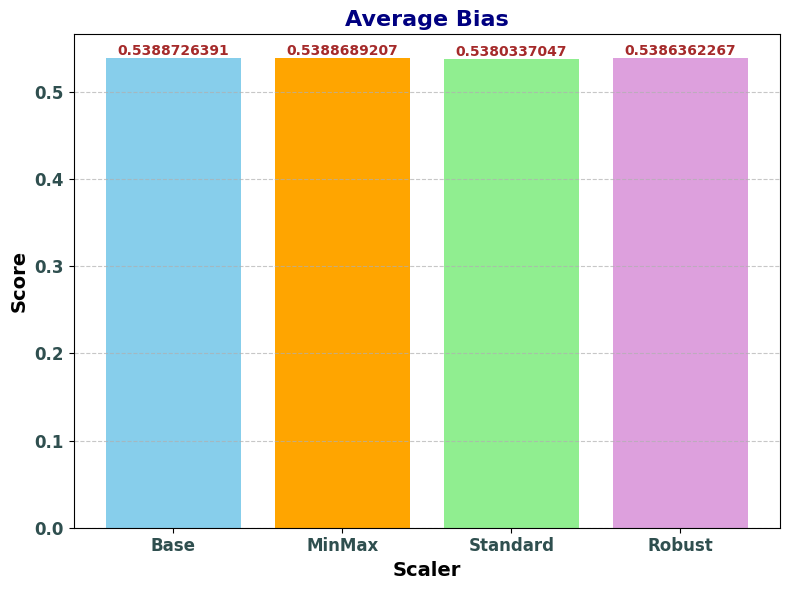

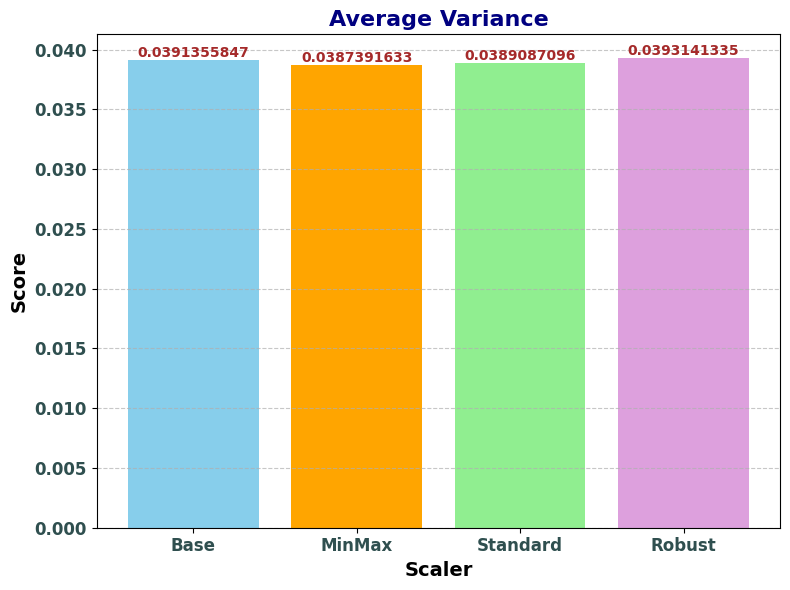

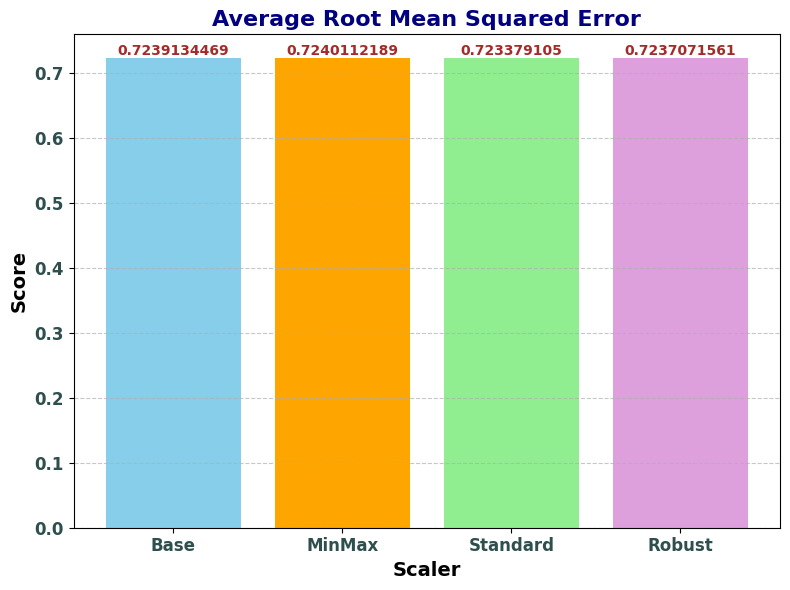

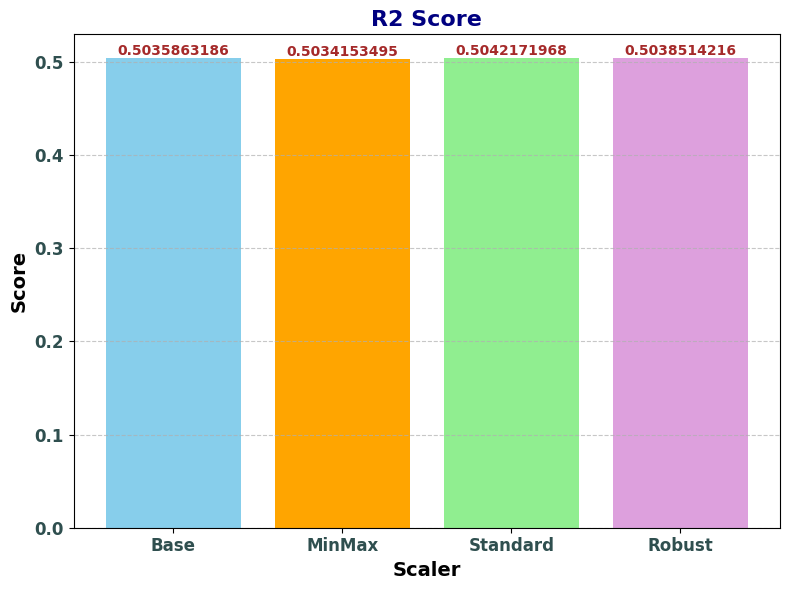

In [42]:
bias = [gbr_base_average_mse, gbr_minmax_average_mse, gbr_standard_average_mse, gbr_robust_average_mse]
variance = [gbr_base_variance, gbr_minmax_variance, gbr_standard_variance, gbr_robust_variance]
rmse = [gbr_base_average_rmse, gbr_minmax_average_rmse, gbr_standard_average_rmse, gbr_robust_average_rmse]
r2 = [gbr_base_average_r2, gbr_minmax_average_r2, gbr_standard_average_r2, gbr_robust_average_r2]
labels = ['Base', 'MinMax', 'Standard', 'Robust']

plot_bar_chart(bias, labels, 'Average Bias', 'Scaler', 'Score')
plot_bar_chart(variance, labels, 'Average Variance', 'Scaler', 'Score')
plot_bar_chart(rmse, labels, 'Average Root Mean Squared Error', 'Scaler', 'Score')
plot_bar_chart(r2, labels, 'R2 Score', 'Scaler', 'Score')

### Standard Scaler, Correlation

In [43]:
gbr_standard_correlation_model = GradientBoostingRegressor(random_state=42)
df = silica_df
selected_features = select_features_correlation(df)
df = df[selected_features]

# Split your data into features and target variable
X = df.drop(columns=[df.columns[-1]])
X = standard_scaler(X)
y = df.iloc[:, -1]  # Select the last column as the target variable

# Perform cross-validation using cross_validate_model
gbr_standard_correlation_average_mse, gbr_standard_correlation_average_rmse, gbr_standard_correlation_average_r2, gbr_standard_correlation_all_predictions, gbr_standard_correlation_all_actual_values, gbr_standard_correlation_variance = cross_validate_model(gbr_standard_correlation_model, X.values, y.values)

print("Gradient Boosting Regressor")
print("Average Bias: ", gbr_standard_correlation_average_mse)
print("Variance: ", gbr_standard_correlation_variance)
print("Average RMSE: ", gbr_standard_correlation_average_rmse)
print("Average R2 Score: ", gbr_standard_correlation_average_r2)

Gradient Boosting Regressor
Average Bias:  0.4498647495579135
Variance:  0.008365956447607356
Average RMSE:  0.6673584477960276
Average R2 Score:  0.5626992434973288


### Plot

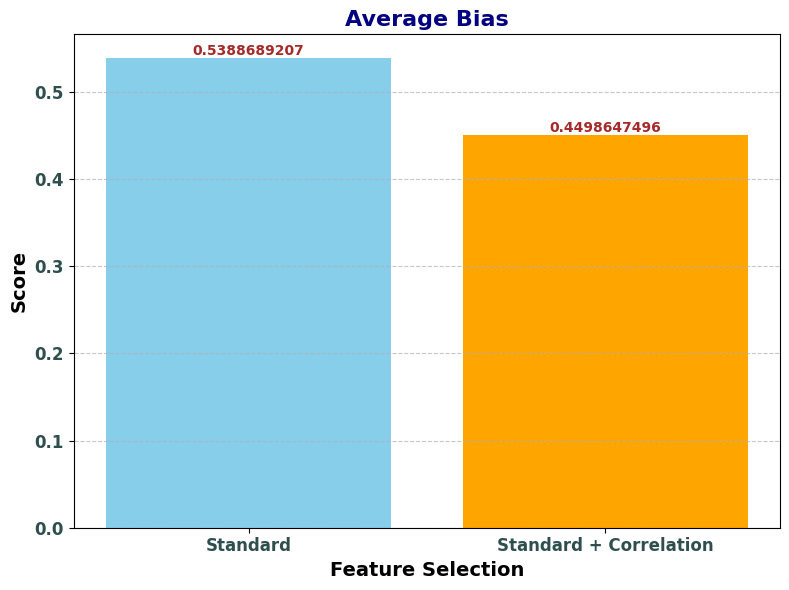

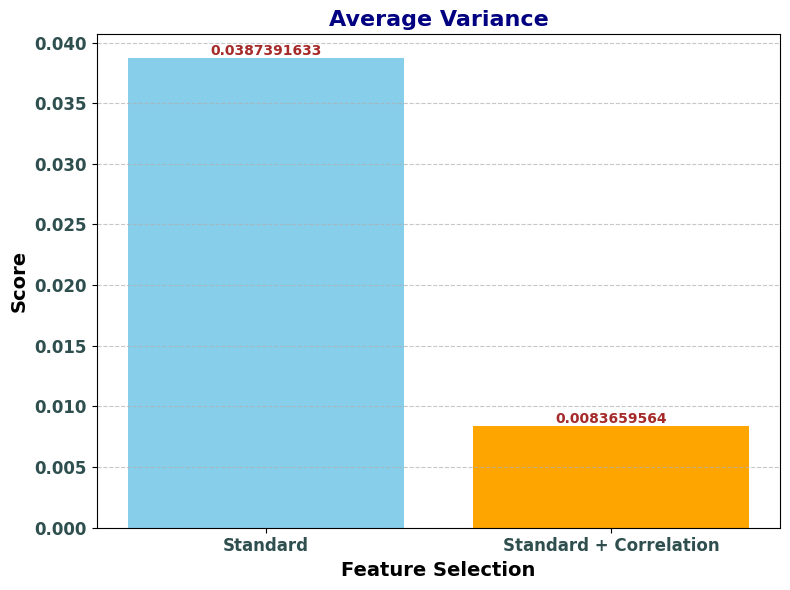

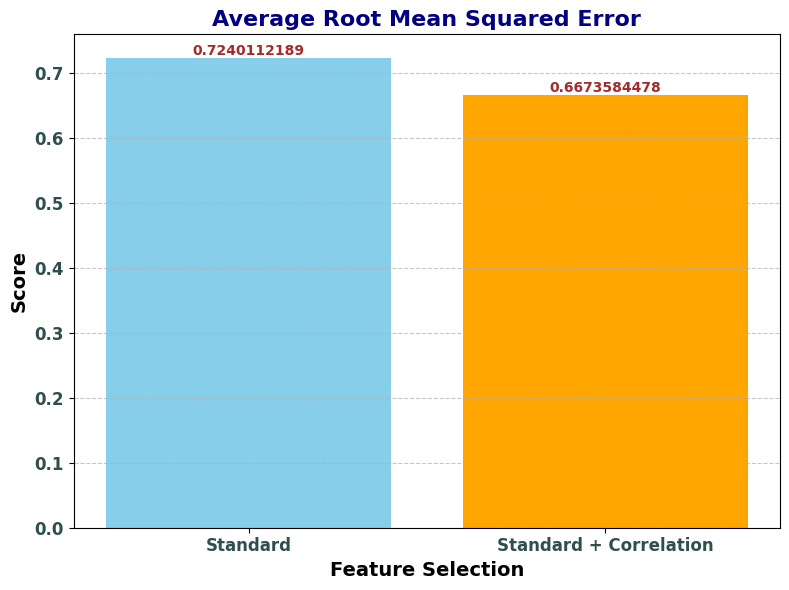

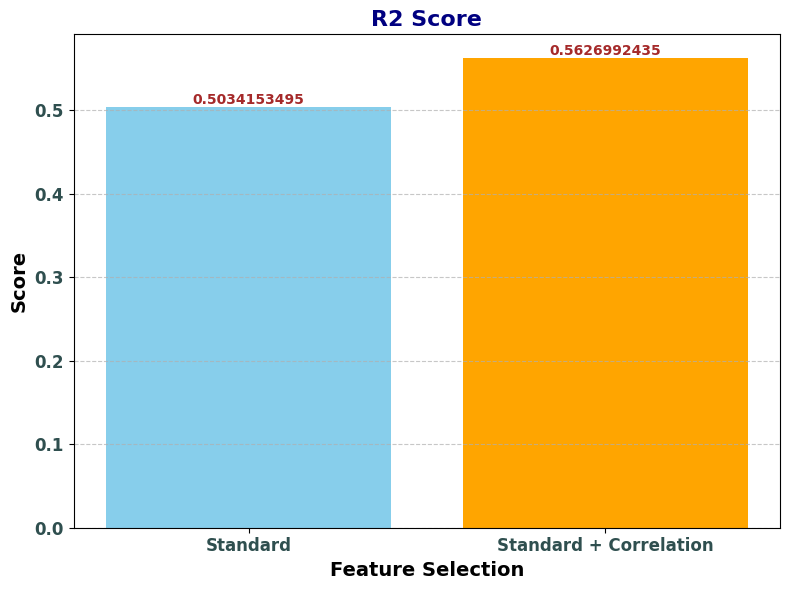

In [44]:
bias = [gbr_minmax_average_mse, gbr_standard_correlation_average_mse]
variance = [gbr_minmax_variance, gbr_standard_correlation_variance]
rmse = [gbr_minmax_average_rmse, gbr_standard_correlation_average_rmse]
r2 = [ gbr_minmax_average_r2, gbr_standard_correlation_average_r2]
labels = ['Standard', 'Standard + Correlation']

plot_bar_chart(bias, labels, 'Average Bias', 'Feature Selection', 'Score')
plot_bar_chart(variance, labels, 'Average Variance', 'Feature Selection', 'Score')
plot_bar_chart(rmse, labels, 'Average Root Mean Squared Error', 'Feature Selection', 'Score')
plot_bar_chart(r2, labels, 'R2 Score', 'Feature Selection', 'Score')

## LSTM

### Create LSTM Model

In [45]:
def create_lstm_model(units=30, seq_size=6, optimizer='adam', size=1):
    # Create the LSTM model
    model = Sequential()
    model.add(LSTM(units, input_shape=(seq_size, size)))
    model.add(Dense(1))
    model.compile(loss='mean_squared_error', optimizer=optimizer)
    return model

### Create LSTM Sequence (Time Step)

In [46]:
def create_sequences(X, y, sequence_length):
    X_sequences, y_sequences = [], []
    for i in range(len(X) - sequence_length + 1):
        X_sequences.append(X[i:i+sequence_length])
        y_sequences.append(y[i+sequence_length-1])
    return np.array(X_sequences), np.array(y_sequences)

### MinMax

In [47]:
df = silica_df.copy()

# Separate features and target variable
X = df.iloc[:, :-1]  # Features (excluding the last column)
y = df.iloc[:, -1]   # Target variable (last column)

# Normalize the features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Define sequence length
sequence_length = 6

# Convert to sequences
x, y = create_sequences(X_scaled, y, sequence_length)

# Initialize TimeSeriesSplit
timesplit = TimeSeriesSplit(n_splits=5)

# Create the LSTM model
lstm_minmax_model = create_lstm_model(size=x.shape[2])

# Perform cross-validation and get results
lstm_minmax_average_mse, lstm_minmax_average_rmse, lstm_minmax_average_r2, lstm_minmax_all_predictions, lstm_minmax_all_actual_values, lstm_minmax_variance = lstm_cross_validate_model(lstm_minmax_model, x, y, timesplit)


print("LSTM")
print("Average Bias: ", lstm_minmax_average_mse)
print("Variance: ", lstm_minmax_variance)
print("Average RMSE: ", lstm_minmax_average_rmse)
print("Average R2 Score: ", lstm_minmax_average_r2)

Epoch 1/20
21/21 [==============================] - 2s 5ms/step - loss: 4.8131
Epoch 2/20
21/21 [==============================] - 0s 5ms/step - loss: 1.5206
Epoch 3/20
21/21 [==============================] - 0s 5ms/step - loss: 1.3543
Epoch 4/20
21/21 [==============================] - 0s 5ms/step - loss: 1.3075
Epoch 5/20
21/21 [==============================] - 0s 5ms/step - loss: 1.2716
Epoch 6/20
21/21 [==============================] - 0s 5ms/step - loss: 1.2380
Epoch 7/20
21/21 [==============================] - 0s 5ms/step - loss: 1.1931
Epoch 8/20
21/21 [==============================] - 0s 5ms/step - loss: 1.1220
Epoch 9/20
21/21 [==============================] - 0s 5ms/step - loss: 1.0523
Epoch 10/20
21/21 [==============================] - 0s 5ms/step - loss: 0.9503
Epoch 11/20
21/21 [==============================] - 0s 4ms/step - loss: 0.8599
Epoch 12/20
21/21 [==============================] - 0s 4ms/step - loss: 0.8024
Epoch 13/20
21/21 [==============================

### Standard

In [48]:
df = silica_df.copy()

# Separate features and target variable
X = df.iloc[:, :-1]  # Features (excluding the last column)
y = df.iloc[:, -1]   # Target variable (last column)

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define sequence length
sequence_length = 6

# Convert to sequences
x, y = create_sequences(X_scaled, y, sequence_length)

# Initialize TimeSeriesSplit
timesplit = TimeSeriesSplit(n_splits=5)

# Create the LSTM model
lstm_standard_model = create_lstm_model(size=x.shape[2])

# Perform cross-validation and get results
lstm_standard_average_mse, lstm_standard_average_rmse, lstm_standard_average_r2, lstm_standard_all_predictions, lstm_standard_all_actual_values, lstm_standard_variance = lstm_cross_validate_model(lstm_standard_model, x, y, timesplit)

print("LSTM")
print("Average Bias: ", lstm_standard_average_mse)
print("Variance: ", lstm_standard_variance)
print("Average RMSE: ", lstm_standard_average_rmse)
print("Average R2 Score: ", lstm_standard_average_r2)

Epoch 1/20
21/21 [==============================] - 2s 5ms/step - loss: 5.0121
Epoch 2/20
21/21 [==============================] - 0s 5ms/step - loss: 2.0347
Epoch 3/20
21/21 [==============================] - 0s 5ms/step - loss: 1.3631
Epoch 4/20
21/21 [==============================] - 0s 5ms/step - loss: 1.0027
Epoch 5/20
21/21 [==============================] - 0s 5ms/step - loss: 0.7821
Epoch 6/20
21/21 [==============================] - 0s 5ms/step - loss: 0.6331
Epoch 7/20
21/21 [==============================] - 0s 5ms/step - loss: 0.5478
Epoch 8/20
21/21 [==============================] - 0s 5ms/step - loss: 0.4837
Epoch 9/20
21/21 [==============================] - 0s 5ms/step - loss: 0.4399
Epoch 10/20
21/21 [==============================] - 0s 5ms/step - loss: 0.4037
Epoch 11/20
21/21 [==============================] - 0s 5ms/step - loss: 0.3789
Epoch 12/20
21/21 [==============================] - 0s 5ms/step - loss: 0.3503
Epoch 13/20
21/21 [==============================

### Robust

In [49]:
df = silica_df.copy()

# Separate features and target variable
X = df.iloc[:, :-1]  # Features (excluding the last column)
y = df.iloc[:, -1]   # Target variable (last column)

# Normalize the features
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# Define sequence length
sequence_length = 6

# Convert to sequences
x, y = create_sequences(X_scaled, y, sequence_length)

# Initialize TimeSeriesSplit
timesplit = TimeSeriesSplit(n_splits=5)

# Create the LSTM model
lstm_robust_model = create_lstm_model(size=x.shape[2])

# Perform cross-validation and get results
lstm_robust_average_mse, lstm_robust_average_rmse, lstm_robust_average_r2, lstm_robust_all_predictions, lstm_robust_all_actual_values, lstm_robust_variance = lstm_cross_validate_model(lstm_robust_model, x, y, timesplit)

print("LSTM")
print("Average Bias: ", lstm_robust_average_mse)
print("Variance: ", lstm_robust_variance)
print("Average RMSE: ", lstm_robust_average_rmse)
print("Average R2 Score: ", lstm_robust_average_r2)

Epoch 1/20
21/21 [==============================] - 2s 5ms/step - loss: 3.1623
Epoch 2/20
21/21 [==============================] - 0s 5ms/step - loss: 1.8393
Epoch 3/20
21/21 [==============================] - 0s 5ms/step - loss: 1.3000
Epoch 4/20
21/21 [==============================] - 0s 5ms/step - loss: 1.0400
Epoch 5/20
21/21 [==============================] - 0s 5ms/step - loss: 0.9177
Epoch 6/20
21/21 [==============================] - 0s 5ms/step - loss: 0.8373
Epoch 7/20
21/21 [==============================] - 0s 5ms/step - loss: 0.7913
Epoch 8/20
21/21 [==============================] - 0s 5ms/step - loss: 0.7649
Epoch 9/20
21/21 [==============================] - 0s 5ms/step - loss: 0.7379
Epoch 10/20
21/21 [==============================] - 0s 5ms/step - loss: 0.7099
Epoch 11/20
21/21 [==============================] - 0s 5ms/step - loss: 0.6806
Epoch 12/20
21/21 [==============================] - 0s 5ms/step - loss: 0.6629
Epoch 13/20
21/21 [==============================

### Plot

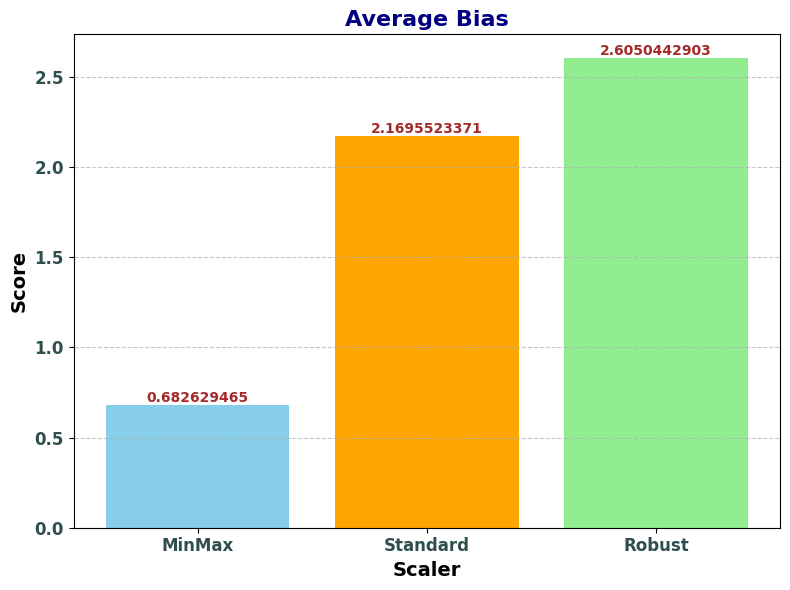

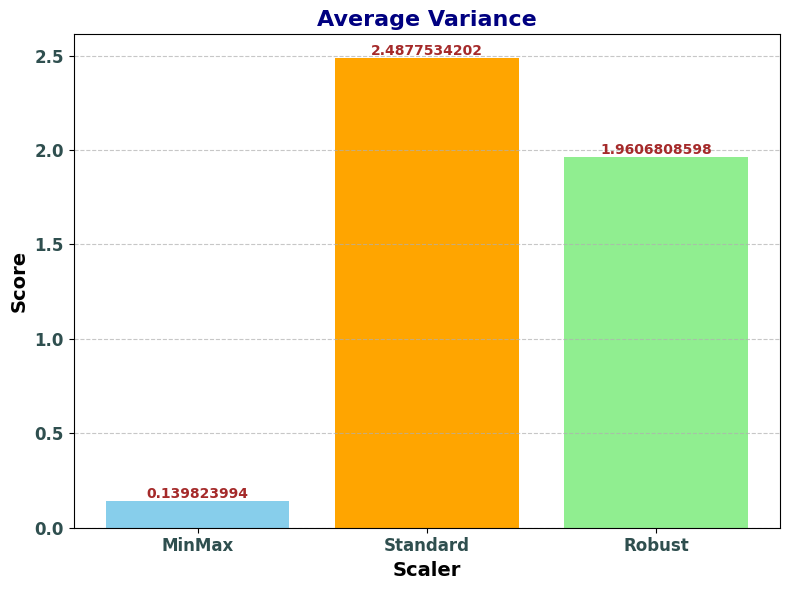

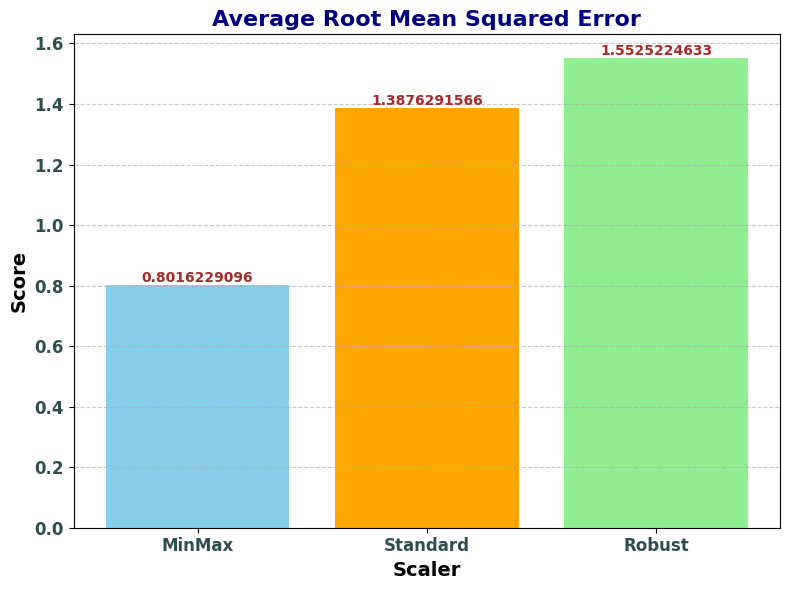

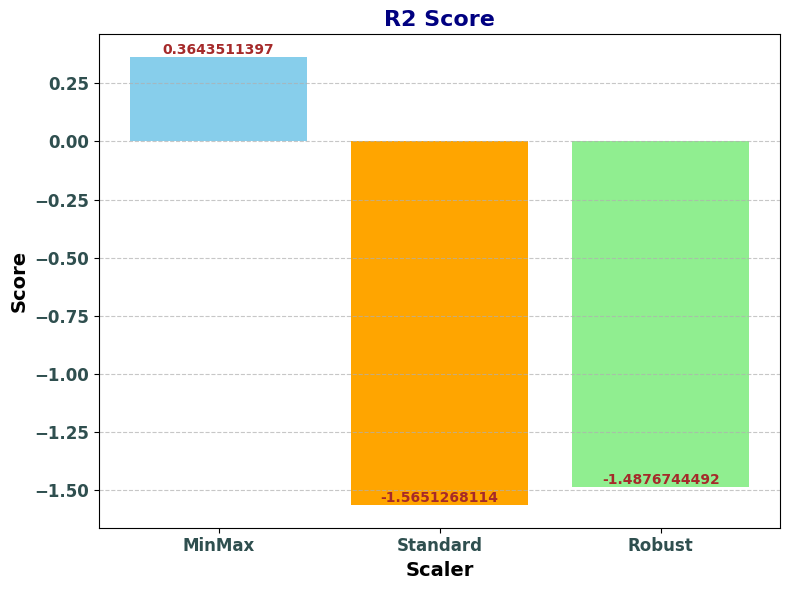

In [50]:
bias = [lstm_minmax_average_mse, lstm_standard_average_mse, lstm_robust_average_mse]
variance = [lstm_minmax_variance, lstm_standard_variance, lstm_robust_variance]
rmse = [lstm_minmax_average_rmse, lstm_standard_average_rmse, lstm_robust_average_rmse]
r2 = [lstm_minmax_average_r2, lstm_standard_average_r2, lstm_robust_average_r2]
labels = ['MinMax', 'Standard', 'Robust']

plot_bar_chart(bias, labels, 'Average Bias', 'Scaler', 'Score')
plot_bar_chart(variance, labels, 'Average Variance', 'Scaler', 'Score')
plot_bar_chart(rmse, labels, 'Average Root Mean Squared Error', 'Scaler', 'Score')
plot_bar_chart(r2, labels, 'R2 Score', 'Scaler', 'Score')

### Min Max, Correlation

In [51]:
df = silica_df
selected_features = select_features_correlation(df)
df = df[selected_features]

# Separate features and target variable
X = df.iloc[:, :-1]  # Features (excluding the last column)
y = df.iloc[:, -1]   # Target variable (last column)

# Normalize the features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Define sequence length
sequence_length = 6

# Convert to sequences
x, y = create_sequences(X_scaled, y, sequence_length)

# Initialize TimeSeriesSplit
timesplit = TimeSeriesSplit(n_splits=5)

# Create the LSTM model
lstm_minmax_correlation_model = create_lstm_model(size=x.shape[2])

# Perform cross-validation and get results
lstm_minmax_correlation_average_mse, lstm_minmax_correlation_average_rmse, lstm_minmax_correlation_average_r2, lstm_minmax_correlation_all_predictions, lstm_minmax_correlation_all_actual_values, lstm_minmax_correlation_variance = lstm_cross_validate_model(lstm_minmax_correlation_model, x, y, timesplit)

print("LSTM")
print("Average Bias: ", lstm_minmax_correlation_average_mse)
print("Variance: ", lstm_minmax_correlation_variance)
print("Average RMSE: ", lstm_minmax_correlation_average_rmse)
print("Average R2 Score: ", lstm_minmax_correlation_average_r2)

Epoch 1/20
21/21 [==============================] - 2s 5ms/step - loss: 6.0759
Epoch 2/20
21/21 [==============================] - 0s 4ms/step - loss: 2.1241
Epoch 3/20
21/21 [==============================] - 0s 5ms/step - loss: 1.4635
Epoch 4/20
21/21 [==============================] - 0s 5ms/step - loss: 1.3784
Epoch 5/20
21/21 [==============================] - 0s 5ms/step - loss: 1.3419
Epoch 6/20
21/21 [==============================] - 0s 5ms/step - loss: 1.3180
Epoch 7/20
21/21 [==============================] - 0s 5ms/step - loss: 1.2948
Epoch 8/20
21/21 [==============================] - 0s 5ms/step - loss: 1.2579
Epoch 9/20
21/21 [==============================] - 0s 4ms/step - loss: 1.2229
Epoch 10/20
21/21 [==============================] - 0s 4ms/step - loss: 1.1785
Epoch 11/20
21/21 [==============================] - 0s 4ms/step - loss: 1.1333
Epoch 12/20
21/21 [==============================] - 0s 4ms/step - loss: 1.0638
Epoch 13/20
21/21 [==============================

### Plot

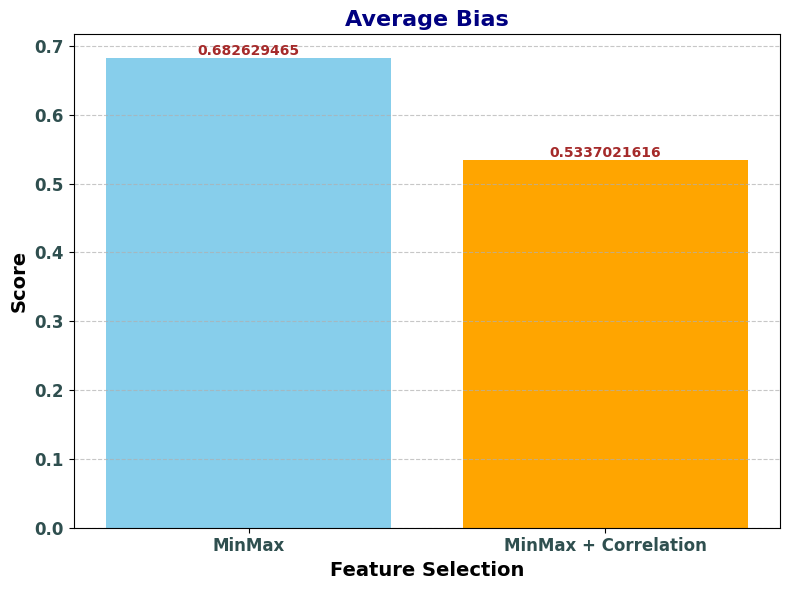

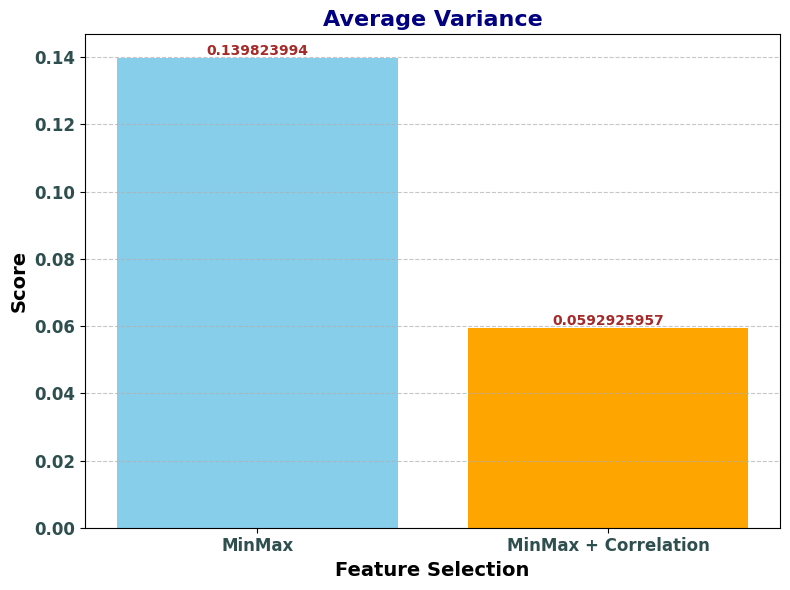

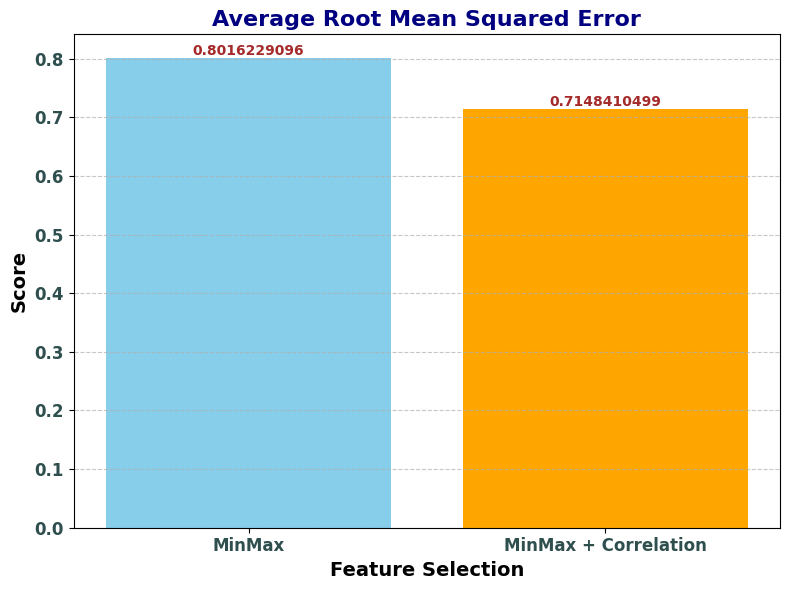

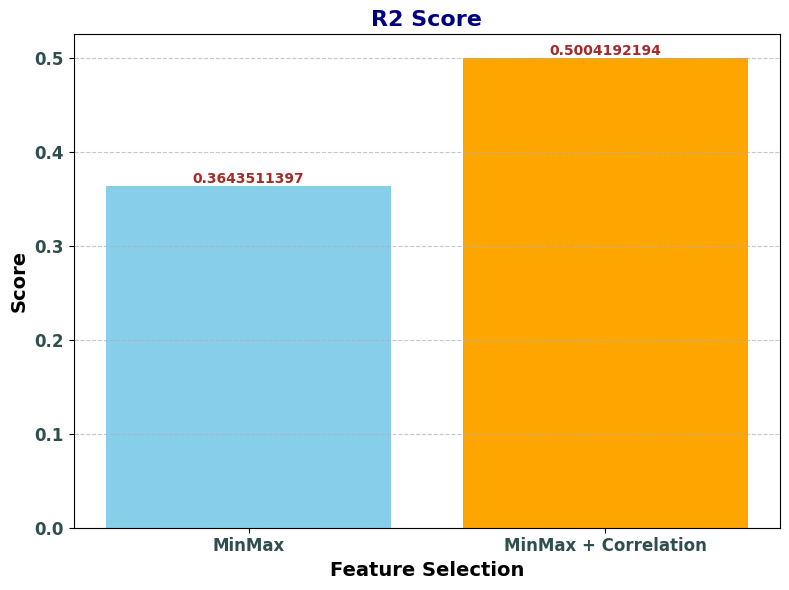

In [52]:
bias = [lstm_minmax_average_mse, lstm_minmax_correlation_average_mse]
variance = [lstm_minmax_variance, lstm_minmax_correlation_variance]
rmse = [lstm_minmax_average_rmse, lstm_minmax_correlation_average_rmse]
r2 = [ lstm_minmax_average_r2, lstm_minmax_correlation_average_r2]
labels = ['MinMax', 'MinMax + Correlation']


plot_bar_chart(bias, labels, 'Average Bias', 'Feature Selection', 'Score')
plot_bar_chart(variance, labels, 'Average Variance', 'Feature Selection', 'Score')
plot_bar_chart(rmse, labels, 'Average Root Mean Squared Error', 'Feature Selection', 'Score')
plot_bar_chart(r2, labels, 'R2 Score', 'Feature Selection', 'Score')

# Part B

## Fine Tuning

### Random Forest Regressor

In [24]:
rfr_model = RandomForestRegressor()
df = silica_df
selected_features = select_features_correlation(df)
df = df[selected_features]

# Split your data into features and target variable
X = df.drop(columns=[df.columns[-1]])
X = standard_scaler(X)
y = df.iloc[:, -1]  # Select the last column as the target variable


# Parameter Tuning
param_grid = {
    'bootstrap': [True],
    'criterion' : ["squared_error", "absolute_error", "friedman_mse", "poisson"],
    'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    'max_features': [2, 3],
    'min_samples_leaf': [1, 2, 3, 4, 5],
    'min_samples_split': [2, 4, 6, 8, 10, 12],
    'n_estimators': [100, 200, 300, 400, 500]
}

# Instantiate the random search model
random_search  = RandomizedSearchCV(estimator = rfr_model, param_distributions = param_grid,
                          cv = 3, n_iter=3, n_jobs = -1, verbose = 2, random_state=42)

# Fit the grid search to the data
random_search.fit(X, y)
print("Best parameters found: ", random_search.best_params_)

best_params = random_search.best_params_
# Add the random_state parameter to the best parameters
best_params['random_state'] = 42
rfr_random_model = RandomForestRegressor(**best_params)

# Perform cross-validation using cross_validate_model
rfr_random_average_mse, rfr_random_average_rmse, rfr_random_average_r2, rfr_random_all_predictions, rfr_random_all_actual_values, rfr_random_variance = cross_validate_model(rfr_random_model, X.values, y.values)

print("Random Forest Regressor")
print("Average Bias: ", rfr_random_average_mse)
print("Variance: ", rfr_random_variance)
print("Average RMSE: ", rfr_random_average_rmse)
print("Average R2 Score: ", rfr_random_average_r2)

Fitting 3 folds for each of 3 candidates, totalling 9 fits


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


Best parameters found:  {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 3, 'max_depth': 80, 'criterion': 'absolute_error', 'bootstrap': True}
Random Forest Regressor
Average Bias:  0.43640060746901604
Variance:  0.011232349064288416
Average RMSE:  0.6562778388943773
Average R2 Score:  0.5888478411004092


### Plot

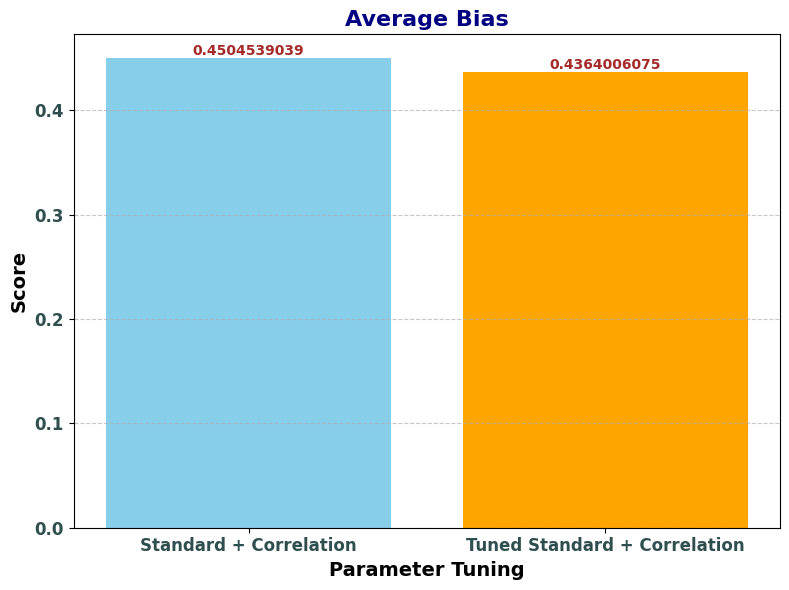

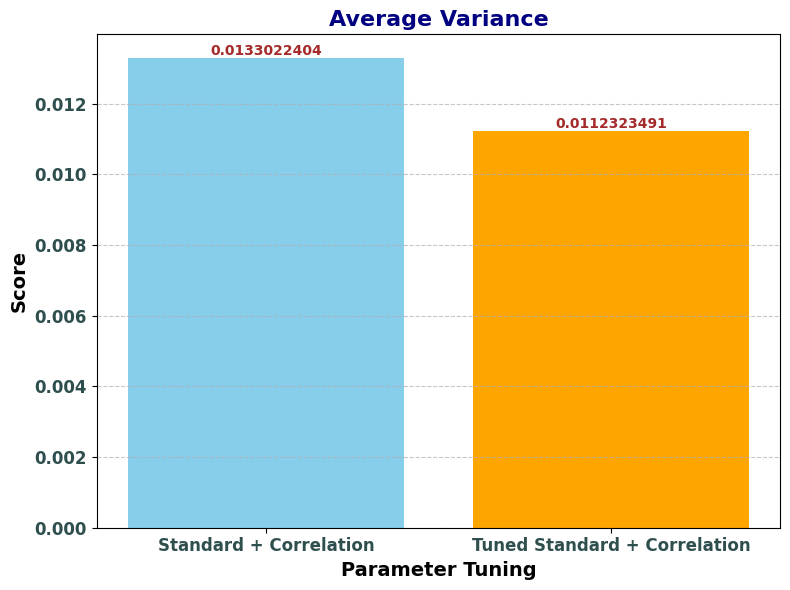

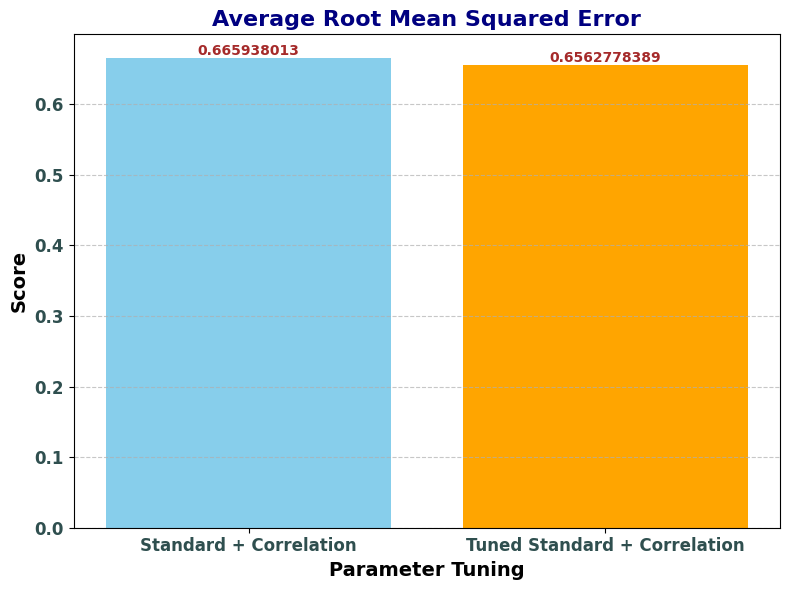

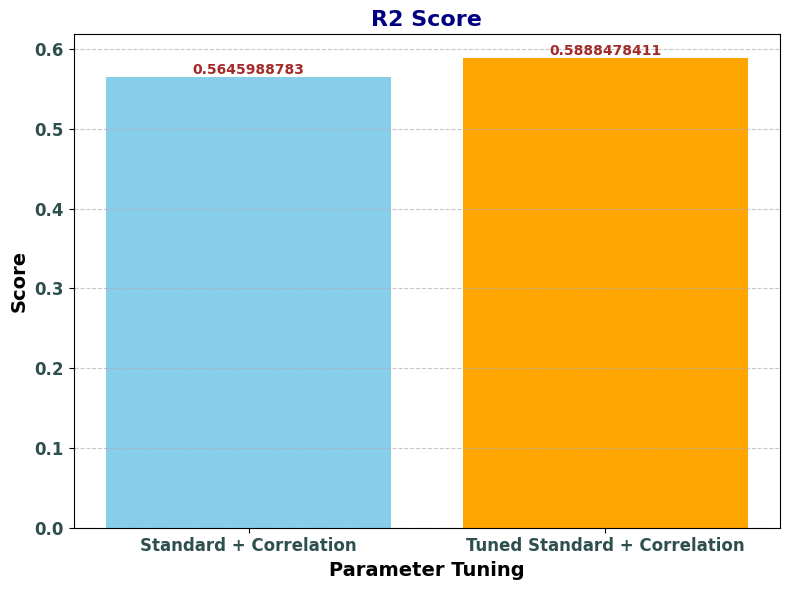

In [28]:
bias = [rfr_standard_correlation_average_mse, rfr_random_average_mse]
variance = [rfr_standard_correlation_variance, rfr_random_variance]
rmse = [rfr_standard_correlation_average_rmse, rfr_random_average_rmse]
r2 = [rfr_standard_correlation_average_r2, rfr_random_average_r2]
labels = ['Standard + Correlation', 'Tuned Standard + Correlation']

plot_bar_chart(bias, labels, 'Average Bias', 'Parameter Tuning', 'Score')
plot_bar_chart(variance, labels, 'Average Variance', 'Parameter Tuning', 'Score')
plot_bar_chart(rmse, labels, 'Average Root Mean Squared Error', 'Parameter Tuning', 'Score')
plot_bar_chart(r2, labels, 'R2 Score', 'Parameter Tuning', 'Score')

### Support Vector Regressor

In [29]:
svr_model = SVR()

# Select relevant features based on correlation
df = silica_df
selected_features = select_features_correlation(df)
df = df[selected_features]

# Split your data into features and target variable
X = df.drop(columns=[df.columns[-1]])
X = min_max_scaler(X)
y = df.iloc[:, -1]  # Select the last column as the target variable


# Parameter Tuning
param_grid = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],  # Different types of kernels
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'gamma': ['scale', 'auto'],  # Kernel coefficient for 'rbf', 'poly', and 'sigmoid'
    'epsilon': [0.1, 0.2, 0.3, 0.4, 0.5]  # Epsilon in the epsilon-SVR model
}

# Instantiate the random search model
random_search  = RandomizedSearchCV(estimator = svr_model, param_distributions = param_grid,
                          cv = 3, n_iter=3, n_jobs = -1, verbose = 2, random_state=42)

# Fit the grid search to the data
random_search.fit(X, y)
print("Best parameters found: ", random_search.best_params_)

best_params = random_search.best_params_
svr_random_model = SVR(**best_params)

# Perform cross-validation using cross_validate_model
svr_random_average_mse, svr_random_average_rmse, svr_random_average_r2, svr_random_aa_predictions, svr_random_all_actual_values, svr_random_variance = cross_validate_model(svr_random_model, X.values, y.values)

print("Support Vector Regressor")
print("Average Bias: ", svr_random_average_mse)
print("Variance: ", svr_random_variance)
print("Average RMSE: ", svr_random_average_rmse)
print("Average R2 Score: ", svr_random_average_r2)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best parameters found:  {'kernel': 'linear', 'gamma': 'auto', 'epsilon': 0.4, 'C': 10}
Support Vector Regressor
Average Bias:  0.44513094466519965
Variance:  0.006409891461729769
Average RMSE:  0.6646775702022674
Average R2 Score:  0.5740647414085134


### Plot

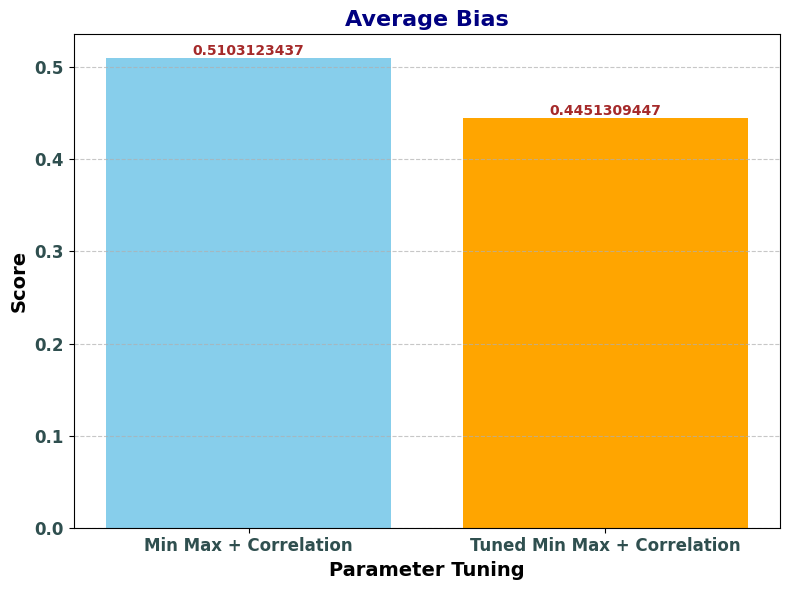

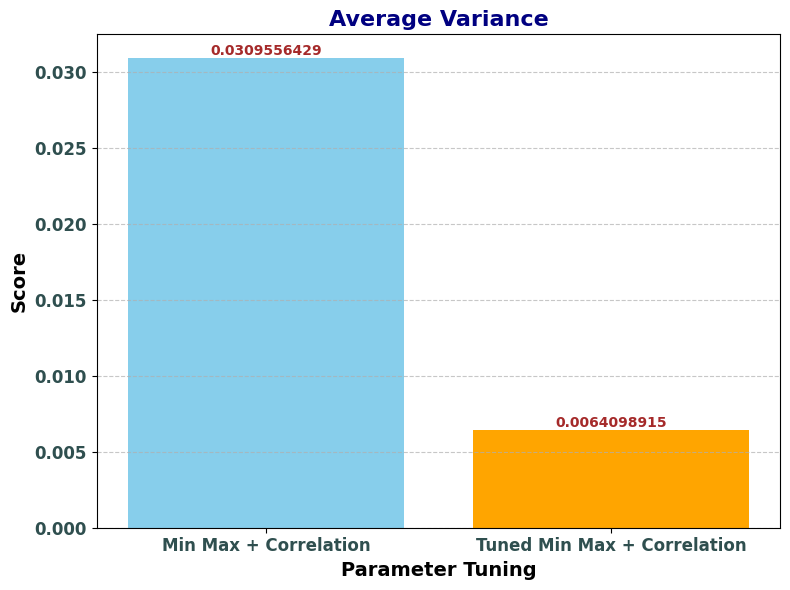

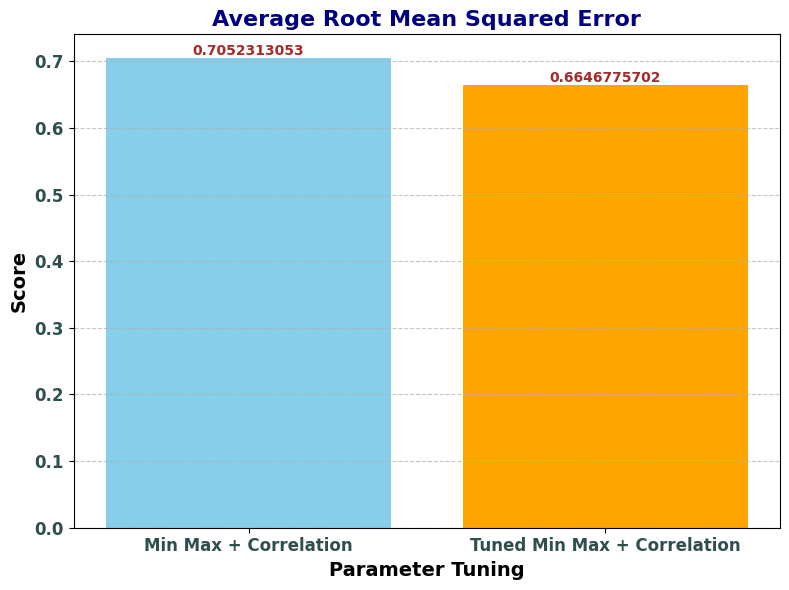

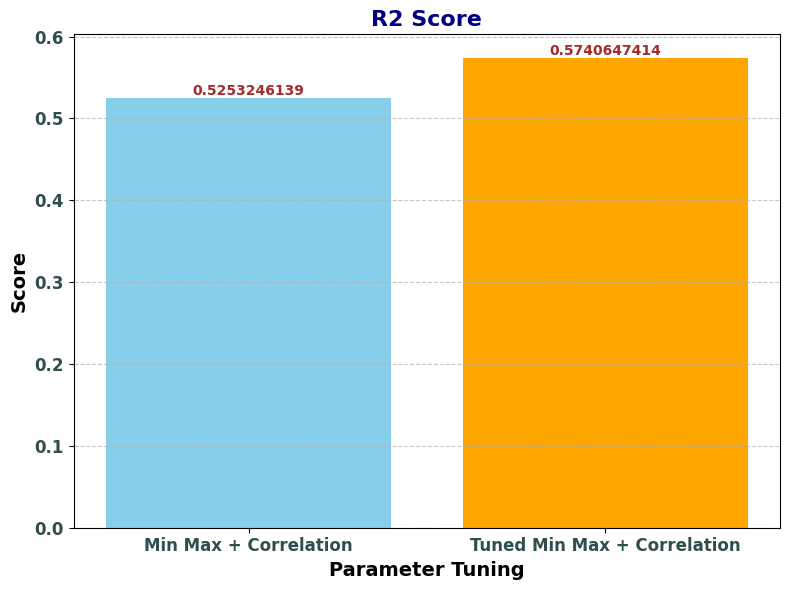

In [30]:
bias = [svr_minmax_correlation_average_mse, svr_random_average_mse]
variance = [svr_minmax_correlation_variance, svr_random_variance]
rmse = [svr_minmax_correlation_average_rmse, svr_random_average_rmse]
r2 = [svr_minmax_correlation_average_r2, svr_random_average_r2]
labels = ['Min Max + Correlation', 'Tuned Min Max + Correlation']

plot_bar_chart(bias, labels, 'Average Bias', 'Parameter Tuning', 'Score')
plot_bar_chart(variance, labels, 'Average Variance', 'Parameter Tuning', 'Score')
plot_bar_chart(rmse, labels, 'Average Root Mean Squared Error', 'Parameter Tuning', 'Score')
plot_bar_chart(r2, labels, 'R2 Score', 'Parameter Tuning', 'Score')

### Gradient Boosting Regressor

In [57]:
gbr_model = GradientBoostingRegressor()

# Select relevant features based on correlation
df = silica_df
selected_features = select_features_correlation(df)
df = df[selected_features]

# Split your data into features and target variable
X = df.drop(columns=[df.columns[-1]])
X = standard_scaler(X)
y = df.iloc[:, -1]  # Select the last column as the target variable

# Parameter Tuning
param_dist = {
    'n_estimators': [50, 100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.1, 0.2, 0.3, 0.4, 0.5],
    'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'max_features': ['auto', 'sqrt', 'log2', None]
}

random_search  = RandomizedSearchCV(estimator = gbr_model, param_distributions=param_dist,
                          cv = 3, n_iter=3, n_jobs = -1, verbose = 2, random_state=42)

random_search.fit(X, y)
print("Best parameters found: ", random_search.best_params_)

best_params = random_search.best_params_
# Add the random_state parameter to the best parameters
best_params['random_state'] = 42
gbr_random_model = GradientBoostingRegressor(**best_params)

# Perform cross-validation using cross_validate_model
gbr_random_average_mse, gbr_random_average_rmse, gbr_random_average_r2, gbr_random_average_predictions, gbr_random_average_actual_values, gbr_random_variance = cross_validate_model(gbr_random_model, X.values, y.values)

print("Gradient Boosting Regressor")
print("Average Bias: ", gbr_random_average_mse)
print("Variance: ", gbr_random_variance)
print("Average RMSE: ", gbr_random_average_rmse)
print("Average R2 Score: ", gbr_random_average_r2)

Fitting 3 folds for each of 3 candidates, totalling 9 fits


/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:277: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:277: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:277: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:277: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
/usr/local/lib/python3.10/di

Best parameters found:  {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 7, 'max_features': 'auto', 'max_depth': 5, 'learning_rate': 0.1}


/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:277: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:277: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:277: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:277: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
/usr/local/lib/python3.10/di

Gradient Boosting Regressor
Average Bias:  0.529189412863597
Variance:  0.015336389221965601
Average RMSE:  0.7225374418882764
Average R2 Score:  0.4809719588485331


/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:277: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:277: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:277: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:277: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(


### Plot

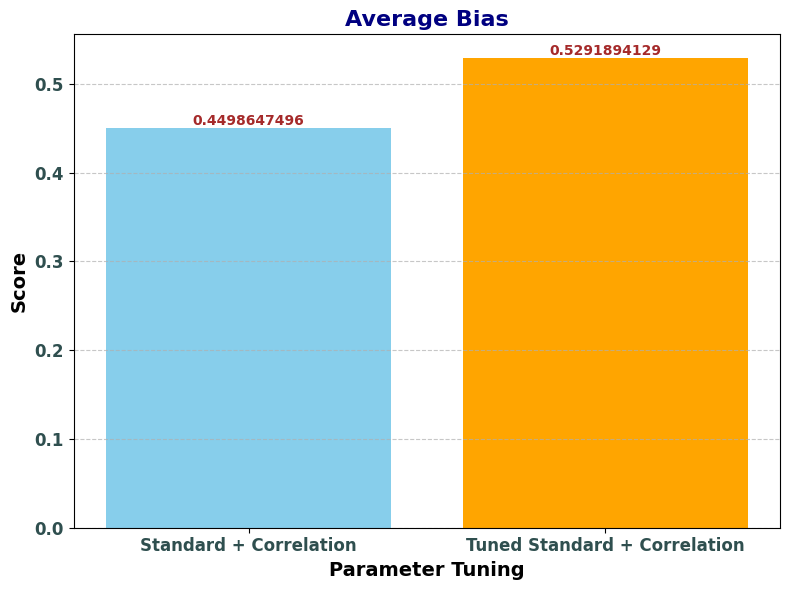

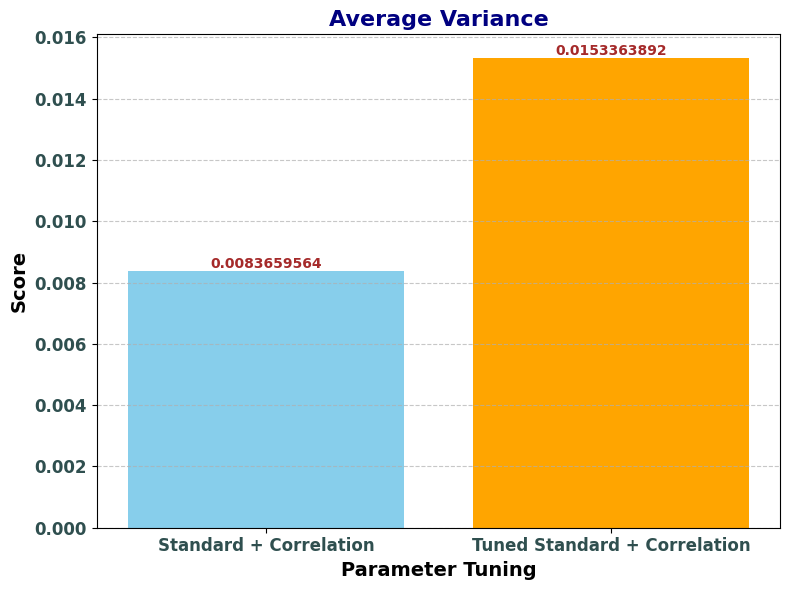

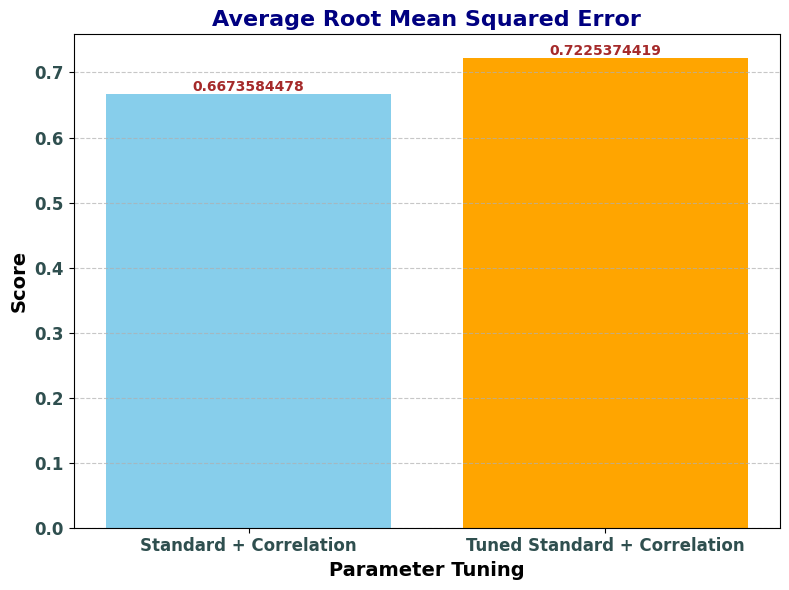

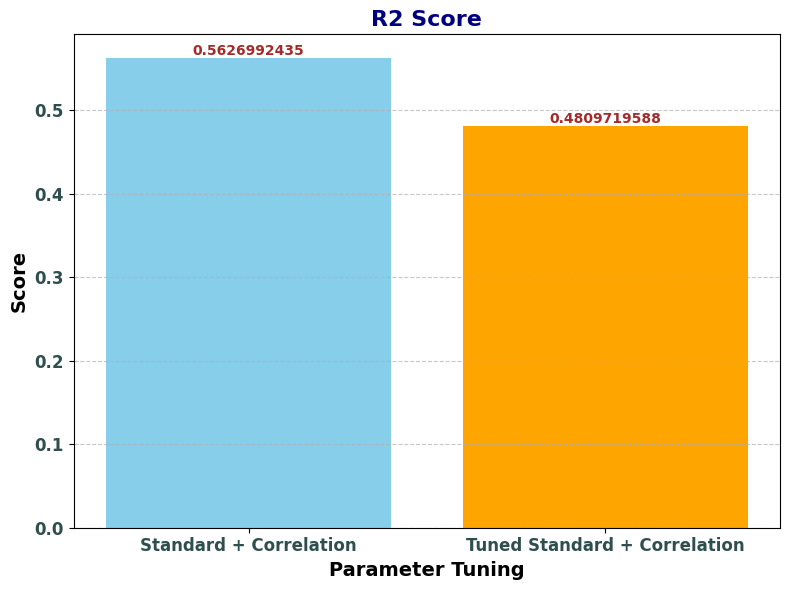

In [58]:
bias = [gbr_standard_correlation_average_mse, gbr_random_average_mse]
variance = [gbr_standard_correlation_variance, gbr_random_variance]
rmse = [gbr_standard_correlation_average_rmse, gbr_random_average_rmse]
r2 = [gbr_standard_correlation_average_r2, gbr_random_average_r2]
labels = ['Standard + Correlation', 'Tuned Standard + Correlation']

plot_bar_chart(bias, labels, 'Average Bias', 'Parameter Tuning', 'Score')
plot_bar_chart(variance, labels, 'Average Variance', 'Parameter Tuning', 'Score')
plot_bar_chart(rmse, labels, 'Average Root Mean Squared Error', 'Parameter Tuning', 'Score')
plot_bar_chart(r2, labels, 'R2 Score', 'Parameter Tuning', 'Score')

### LSTM

In [60]:
df = silica_df
selected_features = select_features_correlation(df)
df = df[selected_features]

# Separate features and target variable
X = df.iloc[:, :-1]  # Features (excluding the last column)
Y = df.iloc[:, -1]   # Target variable (last column)

# Normalize the features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Initialize TimeSeriesSplit
timesplit = TimeSeriesSplit(n_splits=5)

# Define parameter values to tune
units_values = [60, 70 , 80]
optimizer_values = ['adam', 'rmsprop', 'sgd']

results = []

for units in units_values:
    for optimizer in optimizer_values:
        # Convert to sequences with a fixed seq_size
        seq_size = 6  # or any other fixed value you want
        x, y = create_sequences(X_scaled, Y, seq_size)

        # Create the LSTM model with current parameter values
        lstm_tuned_model = create_lstm_model(units=units, optimizer=optimizer, size=x.shape[2])

        # Perform cross-validation and get results
        average_mse, average_rmse, average_r2, all_predictions, all_actual_values, variance = lstm_cross_validate_model(lstm_tuned_model, x, y, timesplit)

        # Store results for comparison
        results.append({
            'units': units,
            'optimizer': optimizer,
            'average_rmse': average_rmse,
            'average_mse': average_mse,
            'average_r2': average_r2,
            'variance': variance
        })

# Print or analyze results as needed
for result in results:
    print("Units:", result['units'])
    print("Optimizer:", result['optimizer'])
    print("Average RMSE:", result['average_rmse'])
    print("Average MSE:", result['average_mse'])
    print("Average R squared:", result['average_r2'])
    print("Variance:", result['variance'])
    print()

Epoch 1/20
21/21 [==============================] - 2s 5ms/step - loss: 4.6311
Epoch 2/20
21/21 [==============================] - 0s 6ms/step - loss: 1.5044
Epoch 3/20
21/21 [==============================] - 0s 6ms/step - loss: 1.3737
Epoch 4/20
21/21 [==============================] - 0s 5ms/step - loss: 1.3126
Epoch 5/20
21/21 [==============================] - 0s 5ms/step - loss: 1.2279
Epoch 6/20
21/21 [==============================] - 0s 5ms/step - loss: 1.1018
Epoch 7/20
21/21 [==============================] - 0s 5ms/step - loss: 0.9578
Epoch 8/20
21/21 [==============================] - 0s 5ms/step - loss: 0.8710
Epoch 9/20
21/21 [==============================] - 0s 5ms/step - loss: 0.8468
Epoch 10/20
21/21 [==============================] - 0s 5ms/step - loss: 0.8212
Epoch 11/20
21/21 [==============================] - 0s 5ms/step - loss: 0.8121
Epoch 12/20
21/21 [==============================] - 0s 5ms/step - loss: 0.7740
Epoch 13/20
21/21 [==============================

### Plot

60
adam


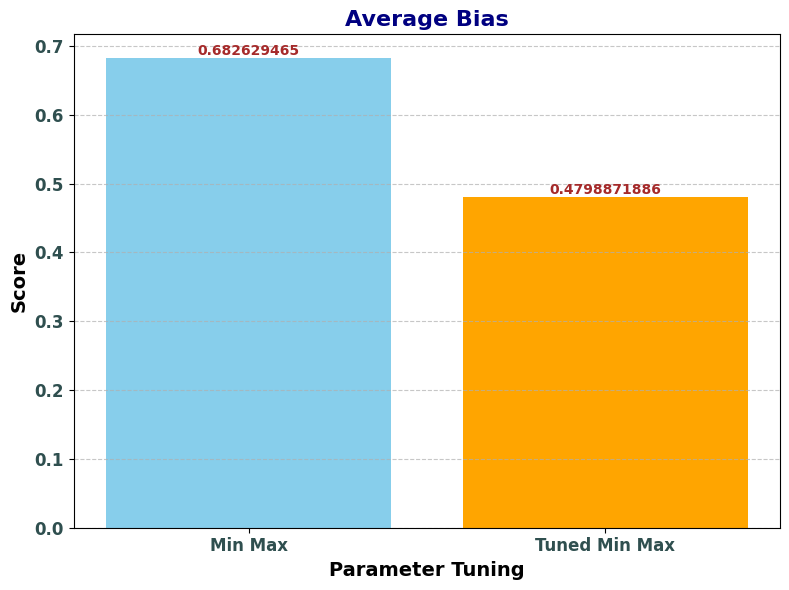

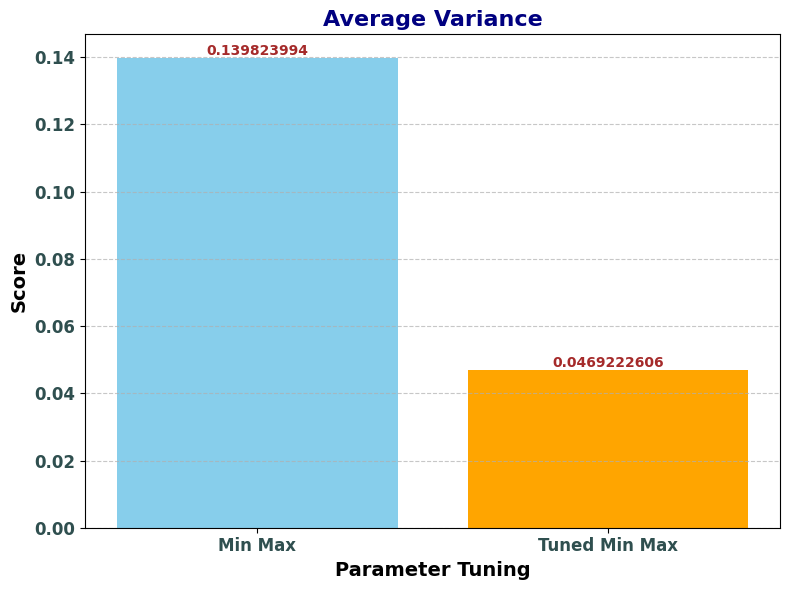

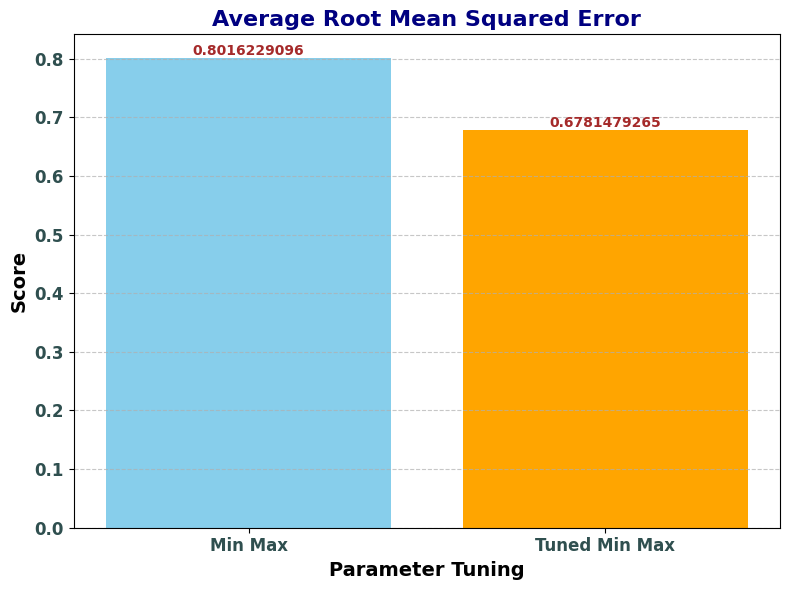

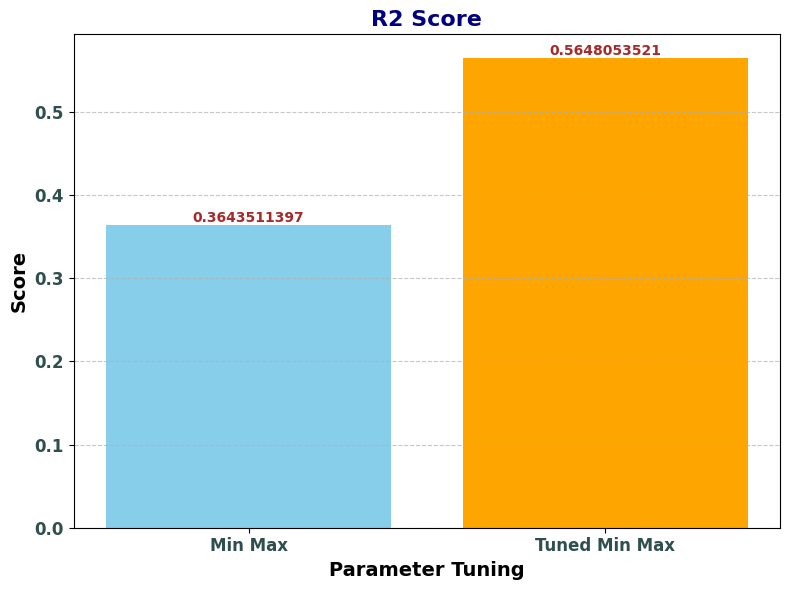

In [62]:
# Initialize variables to store the maximum R squared value and its corresponding index
max_r2 = float('-inf')
lstm_tuned_mse = None
lstm_tuned_variance = None
lstm_tuned_rmse = None
lstm_tuned_r2 = None
lstm_tuned_units = None
lstm_tuned_optimizer = None

# Iterate through the results list
for index, result in enumerate(results):
    # Check if the current R squared value is greater than the maximum R squared value found so far
    if result['average_r2'] > max_r2:
        max_r2 = result['average_r2']
        lstm_tuned_mse = result['average_mse']
        lstm_tuned_variance = result['variance']
        lstm_tuned_rmse = result['average_rmse']
        lstm_tuned_r2 = result['average_r2']
        lstm_tuned_units = result['units']
        lstm_tuned_optimizer = result['optimizer']

bias = [lstm_minmax_average_mse, lstm_tuned_mse]
variance = [lstm_minmax_variance, lstm_tuned_variance]
rmse = [lstm_minmax_average_rmse, lstm_tuned_rmse]
r2 = [lstm_minmax_average_r2, lstm_tuned_r2]
labels = ['Min Max', 'Tuned Min Max']

print(lstm_tuned_units)
print(lstm_tuned_optimizer)

plot_bar_chart(bias, labels, 'Average Bias', 'Parameter Tuning', 'Score')
plot_bar_chart(variance, labels, 'Average Variance', 'Parameter Tuning', 'Score')
plot_bar_chart(rmse, labels, 'Average Root Mean Squared Error', 'Parameter Tuning', 'Score')
plot_bar_chart(r2, labels, 'R2 Score', 'Parameter Tuning', 'Score')

## Ensemble Model

### Weighted Average

#### Random Forest Regressor & Support Vector Machine (Min Max + Correlation)

In [69]:
from sklearn.ensemble import VotingRegressor

df = silica_df
selected_features = select_features_correlation(df)
df = df[selected_features]

# Split your data into features and target variable
X = df.drop(columns=[df.columns[-1]])
X = min_max_scaler(X)
y = df.iloc[:, -1]  # Select the last column as the target variable

ensemble_minmax_voting_regressor = VotingRegressor([('rfr', rfr_random_model), ('svr', svr_random_model)], weights=[0.6, 0.4])
ensemble_minmax_average_mse, ensemble_minmax_average_rmse, ensemble_minmax_average_r2, ensemble_minmax_average_predictions, ensemble_minmax_average_actual_values, ensemble_minmax_variance = cross_validate_model(ensemble_minmax_voting_regressor, X.values, y.values)
print("Voting")
print("Random Forest Regressor & Support Vector Machine (Min Max + Correlation)")
print("Average Bias: ", ensemble_minmax_average_mse)
print("Variance: ", ensemble_minmax_variance)
print("Average RMSE: ", ensemble_minmax_average_rmse)
print("Average R2 Score: ", ensemble_minmax_average_r2)

Voting
Random Forest Regressor & Support Vector Machine (Min Max + Correlation)
Average Bias:  0.41715888812169644
Variance:  0.008473329454851245
Average RMSE:  0.6423432186654852
Average R2 Score:  0.6062967910692512


#### Random Forest Regressor & Support Vector Machine (Standard + Correlation)

In [70]:
from sklearn.ensemble import VotingRegressor

df = silica_df
selected_features = select_features_correlation(df)
df = df[selected_features]

# Split your data into features and target variable
X = df.drop(columns=[df.columns[-1]])
X = standard_scaler(X)
y = df.iloc[:, -1]  # Select the last column as the target variable

ensemble_standard_voting_regressor = VotingRegressor([('rfr', rfr_random_model), ('svr', svr_random_model)], weights=[0.6, 0.4])
ensemble_standard_average_mse, ensemble_standard_average_rmse, ensemble_standard_average_r2, ensemble_standard_average_predictions, ensemble_standard_average_actual_values, ensemble_standard_variance = cross_validate_model(ensemble_standard_voting_regressor, X.values, y.values)
print("Voting")
print("Random Forest Regressor & Support Vector Machine (Standard + Correlation)")
print("Average Bias: ", ensemble_standard_average_mse)
print("Variance: ", ensemble_standard_variance)
print("Average RMSE: ", ensemble_standard_average_rmse)
print("Average R2 Score: ", ensemble_standard_average_r2)

Voting
Random Forest Regressor & Support Vector Machine (Standard + Correlation)
Average Bias:  0.4170245810277141
Variance:  0.008586020126934052
Average RMSE:  0.6421874255107058
Average R2 Score:  0.6066915306785098


#### Plot

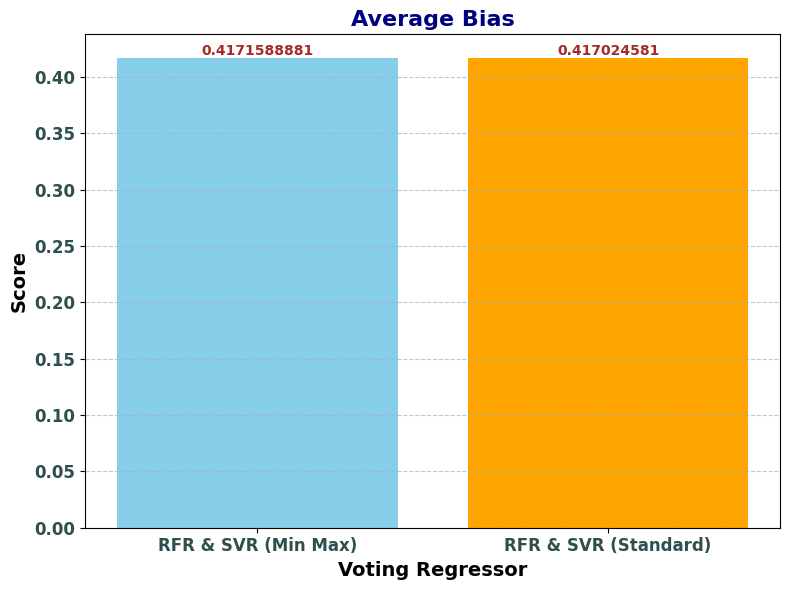

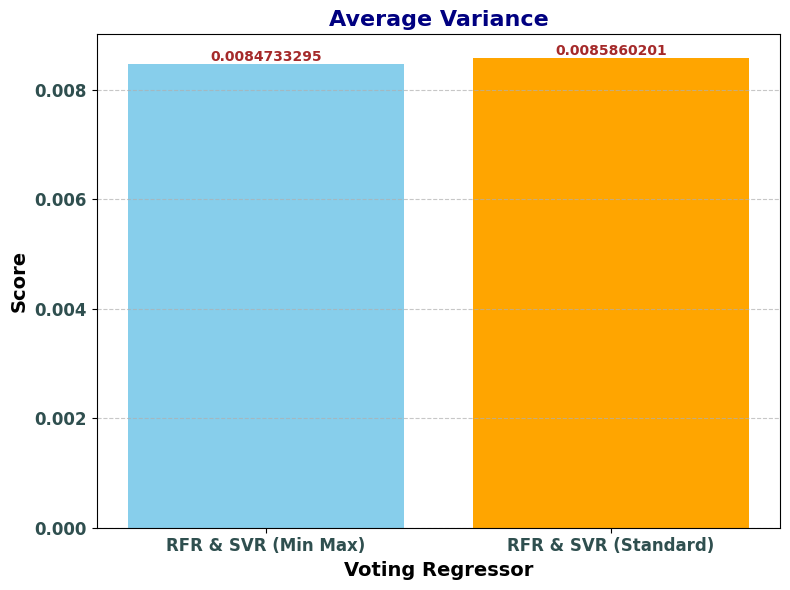

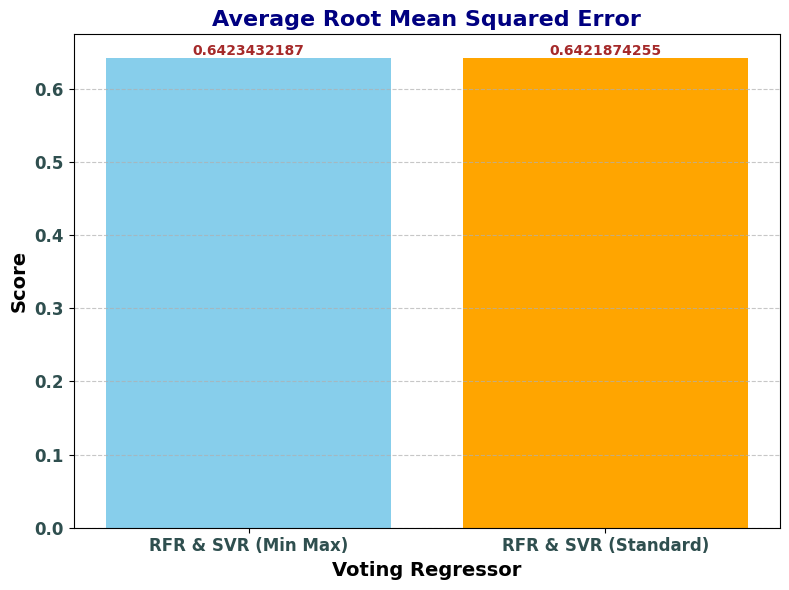

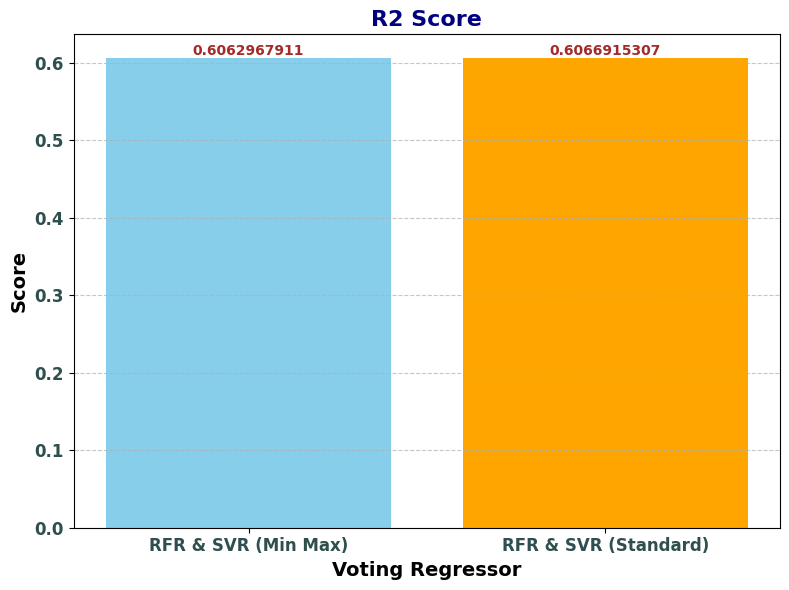

In [71]:
bias = [rfr_random_average_mse, ensemble_minmax_average_mse, ensemble_standard_average_mse]
variance = [rfr_random_variance, ensemble_minmax_variance, ensemble_standard_variance]
rmse = [rfr_random_average_rmse, ensemble_minmax_average_rmse, ensemble_standard_average_rmse]
r2 = [rfr_random_average_r2, ensemble_minmax_average_r2, ensemble_standard_average_r2]
labels = ['RFR & SVR (Min Max)', 'RFR & SVR (Standard)']

plot_bar_chart(bias, labels, 'Average Bias', 'Voting Regressor', 'Score')
plot_bar_chart(variance, labels, 'Average Variance', 'Voting Regressor', 'Score')
plot_bar_chart(rmse, labels, 'Average Root Mean Squared Error', 'Voting Regressor', 'Score')
plot_bar_chart(r2, labels, 'R2 Score', 'Voting Regressor', 'Score')

### Stacking Regressor

#### Random Forest Regressor & Support Vector Machine (Min Max + Correlation)

In [31]:
from sklearn.ensemble import StackingRegressor

df = silica_df
selected_features = select_features_correlation(df)
df = df[selected_features]

# Split your data into features and target variable
X = df.drop(columns=[df.columns[-1]])
X = min_max_scaler(X)
y = df.iloc[:, -1]  # Select the last column as the target variable

stacking_minmax_regressor = StackingRegressor(
    estimators=[('rfr', rfr_random_model)],
    final_estimator= svr_random_model  # Use the support vector regressor as the final estimator
)

stacking_minmax_average_mse, stacking_minmax_average_rmse, stacking_minmax_average_r2, stacking_minmax_average_predictions, stacking_minmax_average_actual_values, stacking_minmax_variance = cross_validate_model(stacking_minmax_regressor, X.values, y.values)
print("Stacking")
print("Random Forest Regressor & Support Vector Machine (Min Max + Correlation)")
print("Average Bias: ", stacking_minmax_average_mse)
print("Variance: ", stacking_minmax_variance)
print("Average RMSE: ", stacking_minmax_average_rmse)
print("Average R2 Score: ", stacking_minmax_average_r2)

Stacking
Random Forest Regressor & Support Vector Machine (Min Max + Correlation)
Average Bias:  0.4420914438916893
Variance:  0.011908464857042746
Average RMSE:  0.6604353739647844
Average R2 Score:  0.5869311730139211


#### Random Forest Regressor & Support Vector Machine (Standard + Correlation)

In [32]:
from sklearn.ensemble import StackingRegressor

df = silica_df
selected_features = select_features_correlation(df)
df = df[selected_features]

# Split your data into features and target variable
X = df.drop(columns=[df.columns[-1]])
X = standard_scaler(X)
y = df.iloc[:, -1]  # Select the last column as the target variable

stacking_standard_regressor = StackingRegressor(
    estimators=[('rfr', rfr_random_model)],
    final_estimator= svr_random_model  # Use the support vector regressor as the final estimator
)

stacking_standard_average_mse, stacking_standard_average_rmse, stacking_standard_average_r2, stacking_standard_average_predictions, stacking_standard_average_actual_values, stacking_standard_variance = cross_validate_model(stacking_standard_regressor, X.values, y.values)
print("Stacking")
print("Random Forest Regressor & Support Vector Machine (Standard + Correlation)")
print("Average Bias: ", stacking_standard_average_mse)
print("Variance: ", stacking_standard_variance)
print("Average RMSE: ", stacking_standard_average_rmse)
print("Average R2 Score: ", stacking_standard_average_r2)

Stacking
Random Forest Regressor & Support Vector Machine (Standard + Correlation)
Average Bias:  0.44281006758583885
Variance:  0.011858294954472685
Average RMSE:  0.6609948271914632
Average R2 Score:  0.5863739899388947


#### Plot

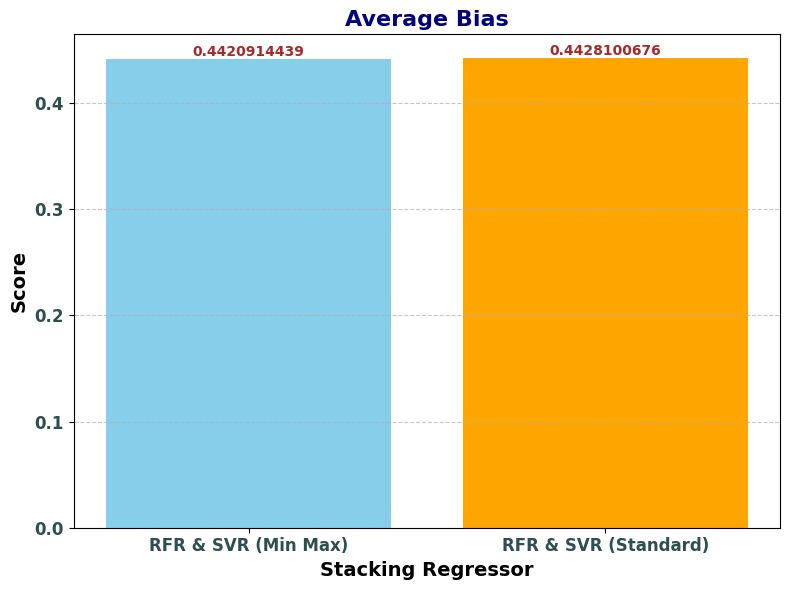

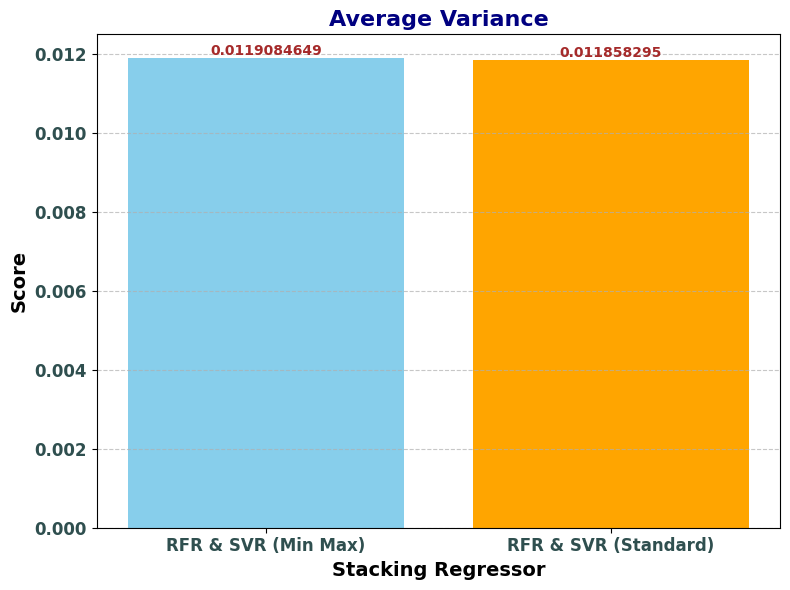

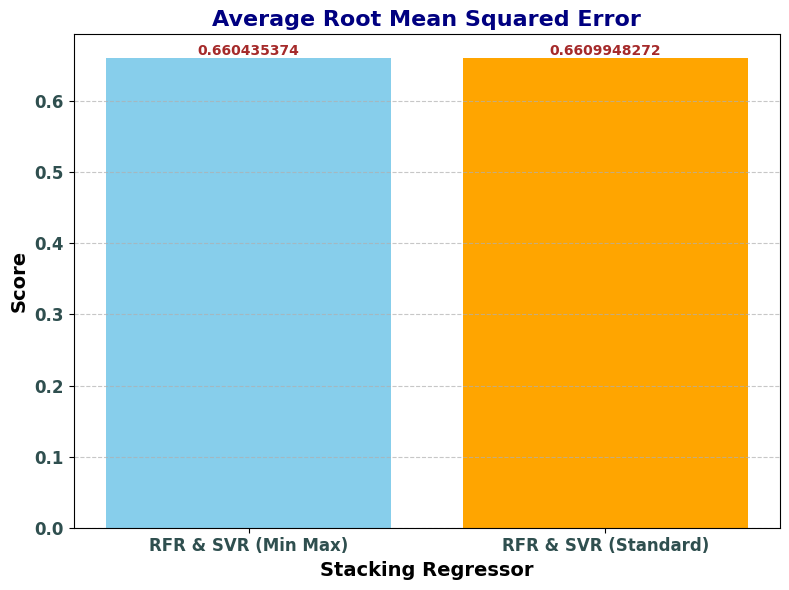

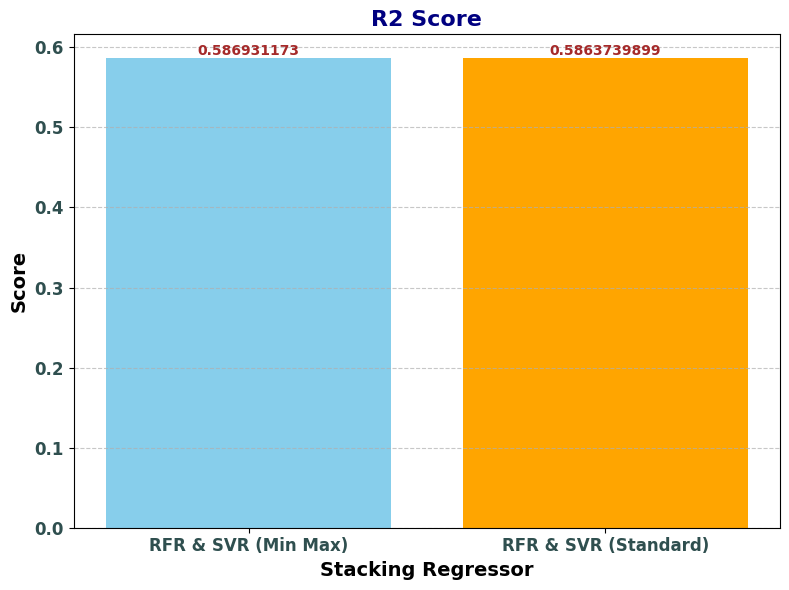

In [33]:
bias = [stacking_minmax_average_mse, stacking_standard_average_mse]
variance = [stacking_minmax_variance, stacking_standard_variance]
rmse = [stacking_minmax_average_rmse, stacking_standard_average_rmse]
r2 = [stacking_minmax_average_r2, stacking_standard_average_r2]
labels = ['RFR & SVR (Min Max)', 'RFR & SVR (Standard)']

plot_bar_chart(bias, labels, 'Average Bias', 'Stacking Regressor', 'Score')
plot_bar_chart(variance, labels, 'Average Variance', 'Stacking Regressor', 'Score')
plot_bar_chart(rmse, labels, 'Average Root Mean Squared Error', 'Stacking Regressor', 'Score')
plot_bar_chart(r2, labels, 'R2 Score', 'Stacking Regressor', 'Score')

# The Best Model (Weighted Average RFR & SVR Tuned Model With Standard Scaler and Correlation)

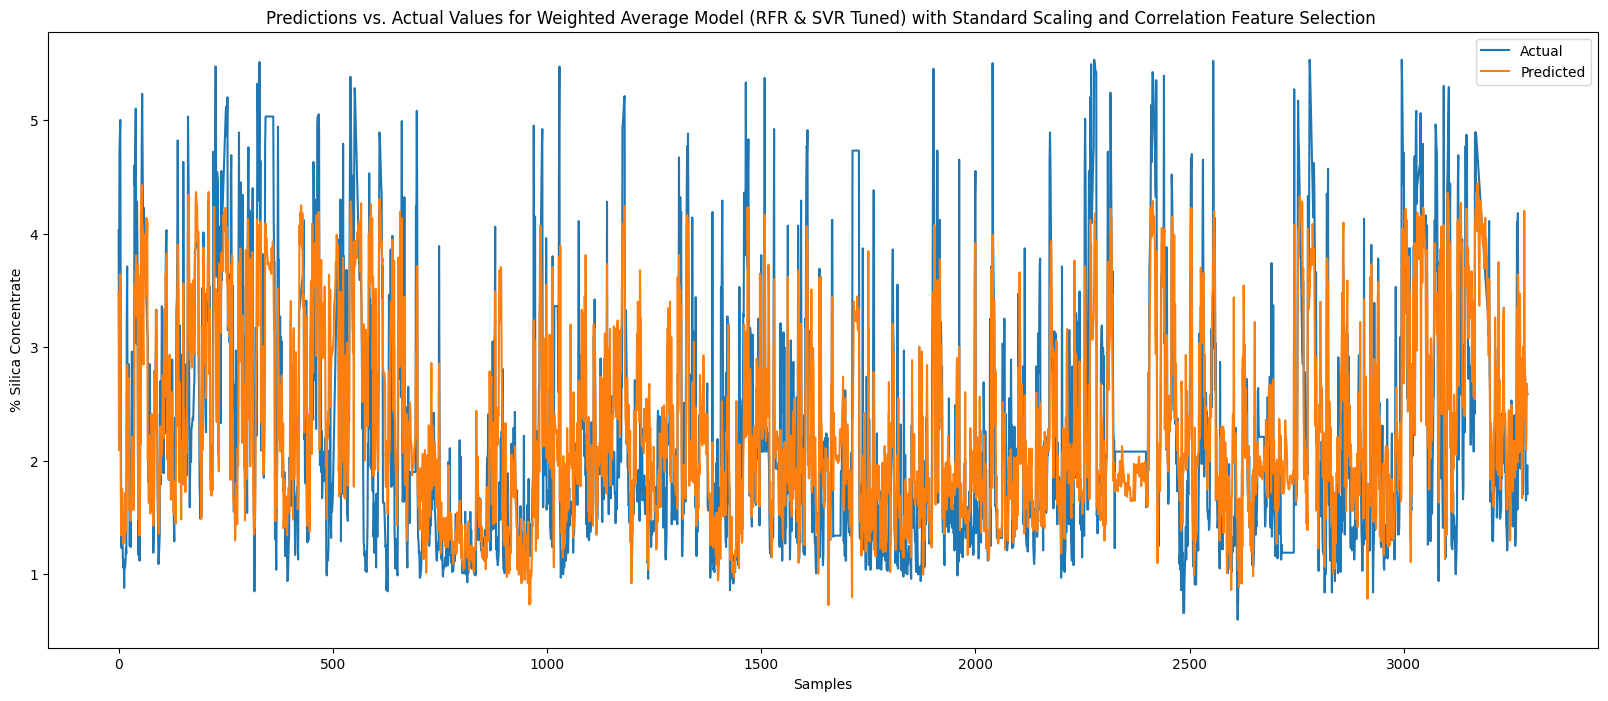

In [79]:
plot_predictions_vs_actual(ensemble_standard_average_predictions, ensemble_standard_average_actual_values, title="Predictions vs. Actual Values for Weighted Average Model (RFR & SVR Tuned) with Standard Scaling and Correlation Feature Selection ", figsize=(20, 8))